# Entregable Aprendizaje No Supervisado 2026

## GRUPO 14:
  - MARIA JOSE KANAGUSUKU
  - NICOLAS URIEL MANSUTTI
  - RAFAEL ANDRES PIGNATA
  - MARIA VALERIA SIEYRA

Utilizar la base de jugadores “male_players.csv” disponible en la página de Kaggle https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv. Consideren que en comparación con la base vista en clase, esta base no tiene los mismos jugadores  y no tiene exactamente el mismo formato.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import hdbscan
import itertools

%matplotlib inline
from matplotlib.patches import Arc, Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D

from sklearn.decomposition import PCA
import umap

import kagglehub
from kagglehub import KaggleDatasetAdapter

import missingno as misno


In [ ]:
df_fifa24 = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "stefanoleone992/ea-sports-fc-24-complete-player-dataset",
    "male_players.csv",
    pandas_kwargs={"low_memory": False},
)
df_fifa24.shape

Using Colab cache for faster access to the 'ea-sports-fc-24-complete-player-dataset' dataset.


(180021, 109)

In [ ]:
df_fifa24

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180016,220806,https://sofifa.com/player/220806/ellis-redman/...,15.0,2.0,2014-09-18,E. Redman,Ellis Redman,CB,41,61,...,38,38,38,37,40,41,41,41,40,10
180017,225509,https://sofifa.com/player/225509/aaron-collins...,15.0,2.0,2014-09-18,A. Collins,Aaron Graham John Collins,ST,41,50,...,30,30,30,31,32,31,31,31,32,14
180018,217591,https://sofifa.com/player/217591/piotr-zemlo/1...,15.0,2.0,2014-09-18,P. Żemło,Piotr Żemło,"LM, LB",40,50,...,46,46,46,48,51-1,53-3,53-3,53-3,51-1,12
180019,222947,https://sofifa.com/player/222947/tom-davies/15...,15.0,2.0,2014-09-18,T. Davies,Thomas Christopher Davies,CB,40,49,...,36,36,36,37,39,40,40,40,39,13


# 1- Análisis exploratorio inicial de la base.


Se espera que el análisis incluya, como mínimo:

  - Dimensiones de la base (cantidad de filas y columnas) y tipos de variables presentes (numéricas, categóricas, identificadores, etc.).

  - Identificación de las columnas relevantes para el objetivo del trabajo (encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). Justificación explícita de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).

  - Detección y tratamiento de valores faltantes (¿qué variables tienen missing values, en qué proporción, y qué se decidió hacer: imputar, descartar filas/columnas, etc.?) y de posibles duplicados.

  - Estadística descriptiva de las variables numéricas relevantes (medidas de tendencia central y dispersión), señalando casos llamativos (rangos inesperados, asimetrías fuertes, outliers evidentes).

  - Distribución de las principales variables categóricas: posición, liga y nacionalidad, entre otras que el grupo considere relevantes, con al menos una visualización por variable.

## Codigo para análsis

In [ ]:
df_fifa24.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Data columns (total 109 columns):
 #    Column                          Non-Null Count   Dtype  
---   ------                          --------------   -----  
 0    player_id                       180021 non-null  int64  
 1    player_url                      180021 non-null  object 
 2    fifa_version                    180021 non-null  float64
 3    fifa_update                     180021 non-null  float64
 4    update_as_of                    180021 non-null  object 
 5    short_name                      180021 non-null  object 
 6    long_name                       180021 non-null  object 
 7    player_positions                180021 non-null  object 
 8    overall                         180021 non-null  int64  
 9    potential                       180021 non-null  int64  
 10   value_eur                       177868 non-null  float64
 11   wage_eur                        178173 non-null  float64
 12   

El dataset está compuesto de 180.021 filas repartidas en 109 columnas, de las cuales pandas identifica que 20 almacenan floats, 43 que almacenan ints y 46 que guardan un tipo denominado _objeto_, este puede ser desde strings hasta estructuras más complejas

In [ ]:
df_fifa24.describe()

,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,180021.000000,180021.000000,180021.0,180021.000000,180021.000000,1.778680e+05,178173.00000,180021.000000,180021.000000,180021.000000,...,147133.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,20024.000000
mean,217326.670294,19.621450,2.0,65.712711,70.779581,2.379142e+06,10638.01081,25.138689,181.287061,75.233356,...,57.837807,45.851456,47.759511,45.764783,16.509979,16.260136,16.129902,16.276951,16.615517,38.750300
std,35215.749284,2.838621,0.0,7.018104,6.255569,6.184358e+06,21637.41400,4.679389,6.764179,6.999181,...,12.305995,20.452502,21.309061,20.899683,17.661659,16.846583,16.499513,17.009393,17.971201,10.578237
min,2.000000,15.000000,2.0,40.000000,40.000000,1.000000e+03,500.00000,16.000000,154.000000,49.000000,...,3.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000
25%,200759.000000,17.000000,2.0,61.000000,66.000000,3.250000e+05,2000.00000,21.000000,176.000000,70.000000,...,50.000000,26.000000,27.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,30.000000
50%,222734.000000,20.000000,2.0,66.000000,71.000000,7.500000e+05,4000.00000,25.000000,181.000000,75.000000,...,59.000000,51.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,40.000000
75%,239858.000000,22.000000,2.0,70.000000,75.000000,1.800000e+06,10000.00000,28.000000,186.000000,80.000000,...,66.000000,63.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,46.000000
max,278145.000000,24.000000,2.0,94.000000,95.000000,1.940000e+08,575000.00000,54.000000,208.000000,110.000000,...,96.000000,94.000000,94.000000,95.000000,91.000000,92.000000,95.000000,92.000000,94.000000,68.000000


In [ ]:
df_fifa24['fifa_version'].value_counts().sort_index()

,count
fifa_version,
15.0,16182
16.0,16706
17.0,17596
18.0,17954
19.0,18086
20.0,18483
21.0,18892
22.0,19239
23.0,18533


El Fifa es un juego con bastante historia y versiones. Como vemos en nuestro dataset, contamos con informacion del fifa 15 hasta el fifa 24. Esto podría traernos un problema de duplicados, porque un mismo jugador puede encontrarse repetido en diferentes versiones, y dado que nuestro objetivo es el de poder reemplazar jugadores (sea por cansancio o por lesion) no tiene mucho sentido cambiar, por ejemplo Messi fifa v.15 por Messi fifa v.18

Decidimos conservar la última version del juego

In [ ]:
print(f"Última versión: {df_fifa24['fifa_version'].max()}")
ultima_version = df_fifa24['fifa_version'].max()
print("Las versiones del FIFA 24 que hay disponibles son:",df_fifa24[df_fifa24['fifa_version'] == ultima_version]['fifa_update'].unique())


df_fc24 = df_fifa24[(df_fifa24['fifa_version'] == ultima_version)].copy()
foot_map = {'Right': 1, 'Left': 0}
df_fc24['preferred_foot_enc'] = df_fc24['preferred_foot'].map(foot_map)

print(df_fc24.shape)

Última versión: 24.0
Las versiones del FIFA 24 que hay disponibles son: [2.]
(18350, 110)


Ahora que nos centramos en una única version del fifa, analicemos si existes duplicados en el dataset o no. Para ello, veamos la cantidad de nombres y IDs únicos en el dataset

In [ ]:
print(f"Cantidad de nombres únicos {len(df_fc24['long_name'].unique())}")
print(f"Cantidad de ids unicos {len(df_fc24['player_id'].unique())}")

Cantidad de nombres únicos 18329
Cantidad de ids unicos 18350



Esto pareciera indicar que hay jugadores repetidos.

Analicemos si hay IDs con más de un jugador asociado.

In [ ]:
# ¿Un mismo player_id aparece siempre con el mismo long_name?
nombres_por_id = df_fc24.groupby('player_id')['long_name'].nunique()

if len(nombres_por_id[nombres_por_id > 1]) == 0:
  print("Todos los IDs tienen un unico nombre asociado")
else:
  print("Hay IDs con más de un nombre asociado")
  print(nombres_por_id[nombres_por_id > 1].sort_values(ascending=False))

Todos los IDs tienen un unico nombre asociado


In [ ]:
# ¿Un mismo long_name aparece siempre con el mismo player_id?
ids_por_nombre = df_fc24.groupby('long_name')['player_id'].nunique()
ids_por_nombre[ids_por_nombre > 1].sort_values(ascending=False)

,player_id
long_name,
Adam Smith,2
Alexander Johansson,2
Carl Johansson,2
Danny Ward,2
Gideon Mensah,2
Jack Robinson,2
Josh Williams,2
Kacper Przybyłko,2
Mamadou Fofana,2


Vimos que a cada ID le correspondería un nombre único, pero a cada nombre le corresponde más de un único ID. A priori esto pareciera confirmar nuestra sospecha, pero para terminar de asegurarnos, veamos si las fechas de nacimiento para un mismo nombre coinciden (ie son la misma persona pero con dos entradas diferentes) o tenemos homónimos el dataset.

In [ ]:
print(f"Cantidad de IDs duplicados {df_fc24['player_id'].duplicated().sum()}")
print(f"Cantidad de nombres repetidos {df_fc24['long_name'].duplicated().sum()}")

Cantidad de IDs duplicados 0
Cantidad de nombres repetidos 21


In [ ]:
uniques= df_fc24[df_fc24['long_name'].duplicated(keep=False)]['dob']
len(uniques.unique())
if len(uniques.unique()== len(uniques)):
    print("No hay jugadores distintos con la misma fecha de nacimiento")
else:
  print("Hay repretidos")
  print(uniques)

No hay jugadores distintos con la misma fecha de nacimiento


Analicemos ahora la cantidad de nulos (NAN) que tenemos en cada columna

In [ ]:
df_fc24.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 18350 entries, 0 to 18349
Data columns (total 110 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    player_id                       18350 non-null  int64  
 1    player_url                      18350 non-null  object 
 2    fifa_version                    18350 non-null  float64
 3    fifa_update                     18350 non-null  float64
 4    update_as_of                    18350 non-null  object 
 5    short_name                      18350 non-null  object 
 6    long_name                       18350 non-null  object 
 7    player_positions                18350 non-null  object 
 8    overall                         18350 non-null  int64  
 9    potential                       18350 non-null  int64  
 10   value_eur                       18250 non-null  float64
 11   wage_eur                        18263 non-null  float64
 12   age                  

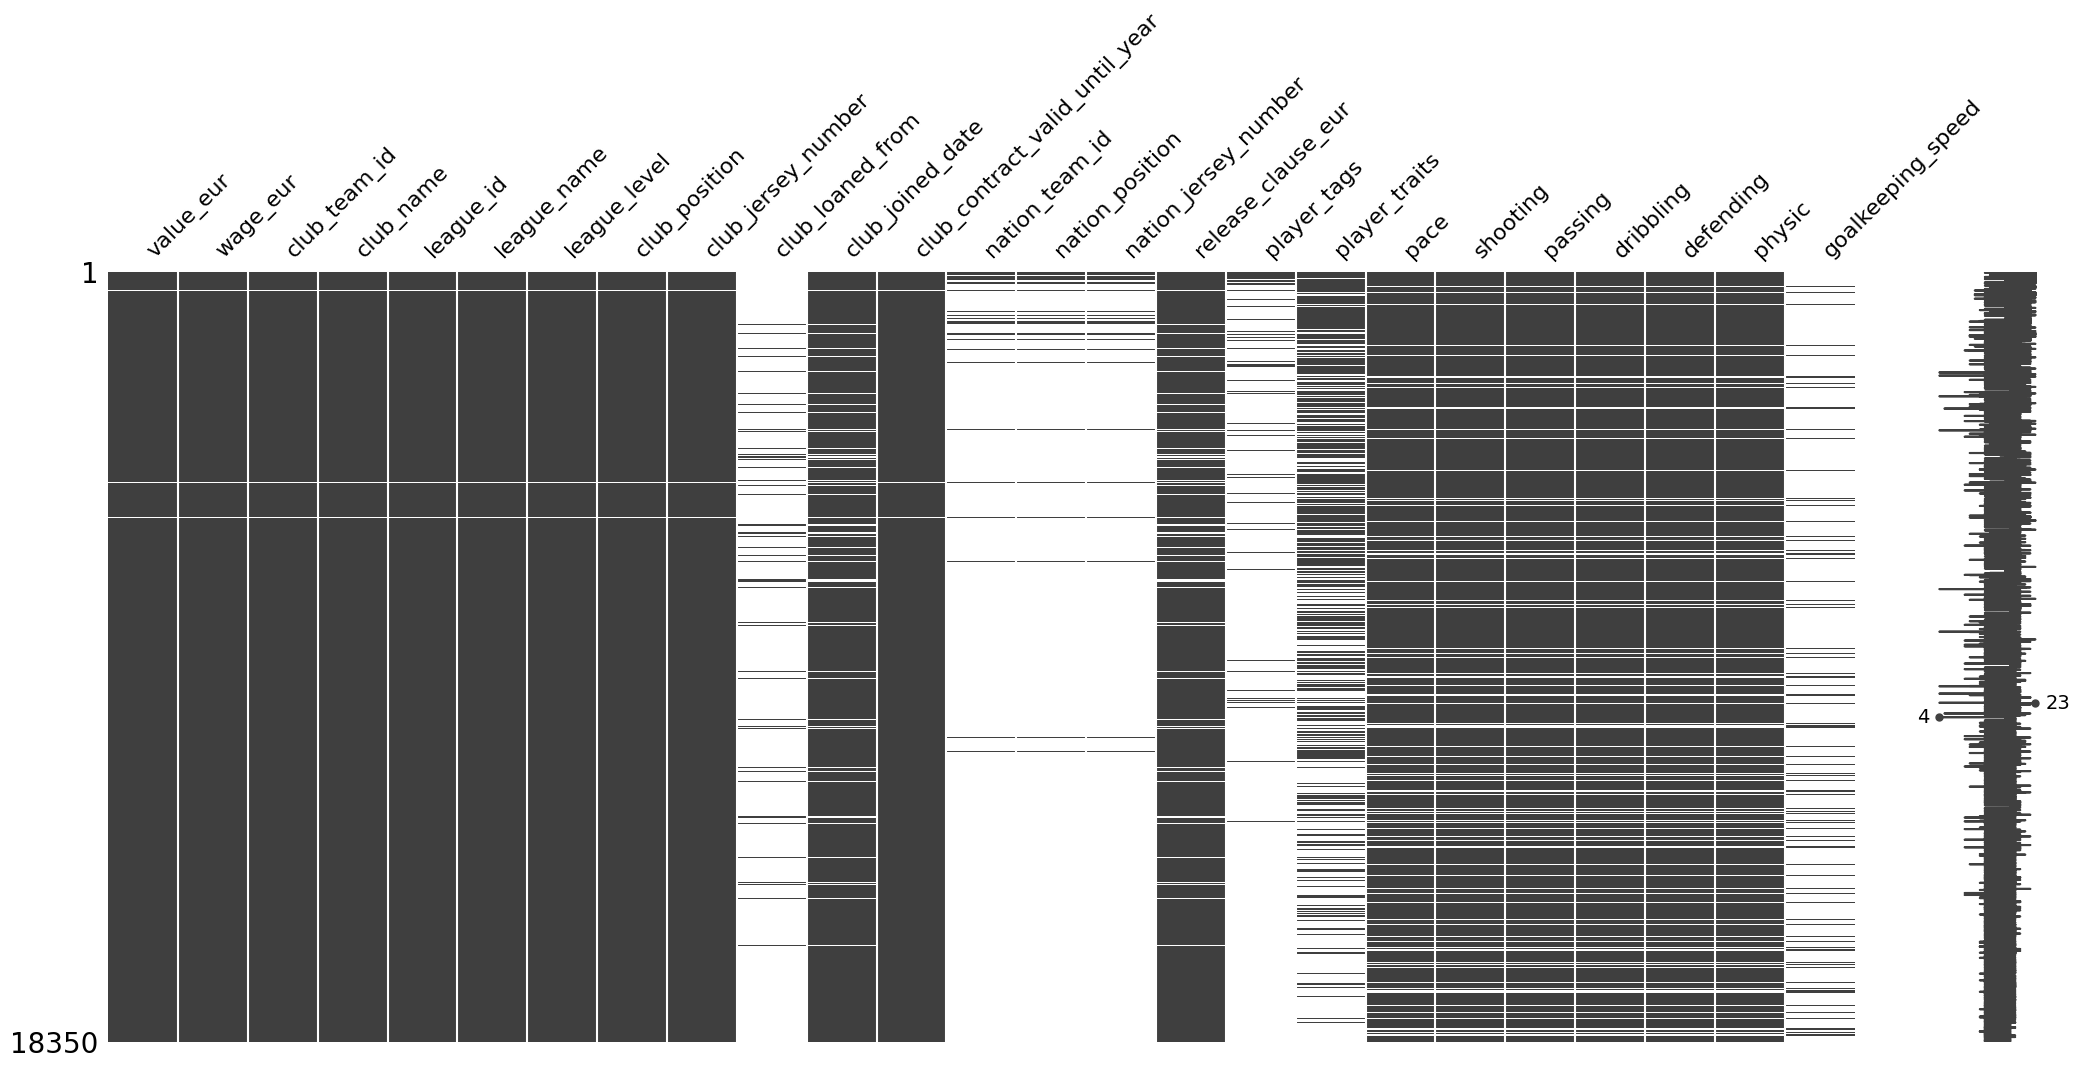

In [ ]:
columnas_nulos=[]

for c in df_fc24.columns:
  if df_fc24[c].isna().sum() > 0:
    columnas_nulos.append(c)


if len(columnas_nulos) > 0:
  misno.matrix(df_fc24[columnas_nulos])

else:
  print("No hay columnas con nulos")

In [ ]:
missing = pd.DataFrame({
    'no_nulos': df_fc24[columnas_nulos].notna().sum(),
    'pct_nulos': (df_fc24[columnas_nulos].isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)

missing

,no_nulos,pct_nulos
nation_team_id,780,95.75
nation_position,780,95.75
nation_jersey_number,780,95.75
club_loaned_from,1180,93.57
player_tags,1252,93.18
goalkeeping_speed,2045,88.86
player_traits,8609,53.08
shooting,16305,11.14
passing,16305,11.14
physic,16305,11.14


Prestemos especial atencion al siguiente fragmento de la tabla de arriba

|columna|cantidad no nulos| % nulos
|---|---|---|
| shooting |	16305 |	11.14 |
| passing |	16305 |	11.14 |
| physic |	16305 |	11.14 |
| dribbling |	16305 |	11.14 |
| defending |	16305 |	11.14 |
| pace | 16305 |	11.14 |

Como se aprecia, todas tienen la misma cantidad de no-nulos y el mismo porcentaje de valores faltantes, analicemos si se debe a alguna posicion en particular

In [ ]:
print(df_fc24[df_fc24['shooting'].isna()]['player_positions'].value_counts())
print(df_fc24[df_fc24['passing'].isna()]['player_positions'].value_counts())
print(df_fc24[df_fc24['physic'].isna()]['player_positions'].value_counts())
print(df_fc24[df_fc24['dribbling'].isna()]['player_positions'].value_counts())
print(df_fc24[df_fc24['defending'].isna()]['player_positions'].value_counts())
print(df_fc24[df_fc24['pace'].isna()]['player_positions'].value_counts())


player_positions
GK    2045
Name: count, dtype: int64
player_positions
GK    2045
Name: count, dtype: int64
player_positions
GK    2045
Name: count, dtype: int64
player_positions
GK    2045
Name: count, dtype: int64
player_positions
GK    2045
Name: count, dtype: int64
player_positions
GK    2045
Name: count, dtype: int64


In [ ]:
print(f"Cantidad de arqueros: {len(df_fc24[df_fc24['player_positions'].str.contains('GK')])}")

Cantidad de arqueros: 2045


Esto nos indica que las columnas que resaltamos previamente no son atributos de arqueros, de manera que la falta de valores en ellas se debe a que, como arqueros, no desempeñan un rol que permita incluir valores en estas columnas en particular.

Esto, sin embargo, nos advierte de otro aspecto, y es que si planeamos hacer clustering, y tenemos sin cuidado a los arqueros, muy probablemente acabemos con 2 clusters bien definidos, jugadores de campo y arqueros, lo cual no nos sirve para nuestro propósito de poder intercambiar jugadores en el partido.

In [ ]:
df_fc24_campo = df_fc24[df_fc24['pace'].notna()].copy()
print(f"Forma del df jugadores de campo: {df_fc24_campo.shape}")

df_fc24_gk = df_fc24[df_fc24['player_positions'].str.contains('GK')].copy()
print(f"Forma del df jugadores de campo: {df_fc24_gk.shape}")

Forma del df jugadores de campo: (16305, 110)
Forma del df jugadores de campo: (2045, 110)


El dataset tiene columnas que, evidentemente, no nos sirven para este análisis (como el player_id o player_url) y otras que evidentemente no nos serán útiles para nuestro propósito (como el peso del jugador). Dejamos afuera también el número de camiseta, edad, o el potencial por ser variables que (si bien pueden ser usadas para ploteos) no indican mucho de la calidad del jugador; potencial es una variable que indica lo máximo que puede mejorarse un jugador-virtual, pero esto depende del jugador-real que esté jugando al Fifa.

Un dato a tener en cuenta es que las columnas `'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic','preferred_foot_enc'` son derivadas de otras dentro del dataset; es decir, para obtener defending, por ejemplo, se realiza un cálculo que involucra todas las variables de defensa. Conviene separar estas columnas derivadas del resto, solo por claridad mental.

In [ ]:
cols_descartadas = [
    'player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of',
    'short_name', 'long_name', 'potential', 'value_eur', 'wage_eur', 'age', 'dob',
    'height_cm', 'weight_kg', 'club_position', 'club_team_id', 'club_name',
    'league_id', 'league_name', 'league_level', 'club_jersey_number',
    'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year',
    'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position',
    'nation_jersey_number', 'international_reputation', 'work_rate', 'body_type',
    'real_face', 'release_clause_eur', 'player_tags', 'player_traits'
]

cols_hab_generales = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic','preferred_foot_enc']

cols_hab_detalladas = [
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
    'mentality_penalties', 'mentality_composure',
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes','preferred_foot_enc'
]

cols_posiciones = [
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram',
    'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
    'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'
]

df_id = df_fc24_campo[cols_descartadas].copy()
df_hab_generales = df_fc24_campo[cols_hab_generales].copy()
df_hab_detalladas = df_fc24_campo[cols_hab_detalladas].copy()
df_posiciones = df_fc24_campo[cols_posiciones].copy()

for nombre, d in [('df_id', df_id), ('df_hab_generales', df_hab_generales),
                   ('df_hab_detalladas', df_hab_detalladas), ('df_posiciones', df_posiciones)]:
    print(nombre, d.shape)

df_id (16305, 36)
df_hab_generales (16305, 7)
df_hab_detalladas (16305, 35)
df_posiciones (16305, 27)


In [ ]:
cols_habilidades = cols_hab_generales + cols_hab_detalladas
assert all(df_fc24[e].dtype == np.int64 or df_fc24[e].dtype == np.float64 for e in cols_habilidades), "Hay columnas que no son numericas"
df_fc24[cols_habilidades].describe().T

,count,mean,std,min,25%,50%,75%,max
pace,16305.0,68.371788,10.766770,27.0,62.0,69.0,76.0,97.0
shooting,16305.0,52.582091,13.900844,19.0,42.0,55.0,63.0,93.0
passing,16305.0,57.489850,9.898202,25.0,51.0,58.0,64.0,94.0
dribbling,16305.0,62.839497,9.448958,28.0,57.0,64.0,69.0,94.0
defending,16305.0,52.093468,16.026187,15.0,38.0,57.0,64.0,89.0
physic,16305.0,64.901564,9.922964,32.0,58.0,66.0,72.0,89.0
preferred_foot_enc,18350.0,0.756240,0.429361,0.0,1.0,1.0,1.0,1.0
attacking_crossing,18350.0,49.291499,17.828376,7.0,39.0,53.0,63.0,95.0
attacking_finishing,18350.0,46.294005,19.729039,3.0,31.0,50.0,62.0,96.0
attacking_heading_accuracy,18350.0,51.794441,17.296979,5.0,44.0,55.0,64.0,93.0


Realicemos ahora un análsis de la distribucion de algunas de las variables, separando entre arqueros y jugadores de campo

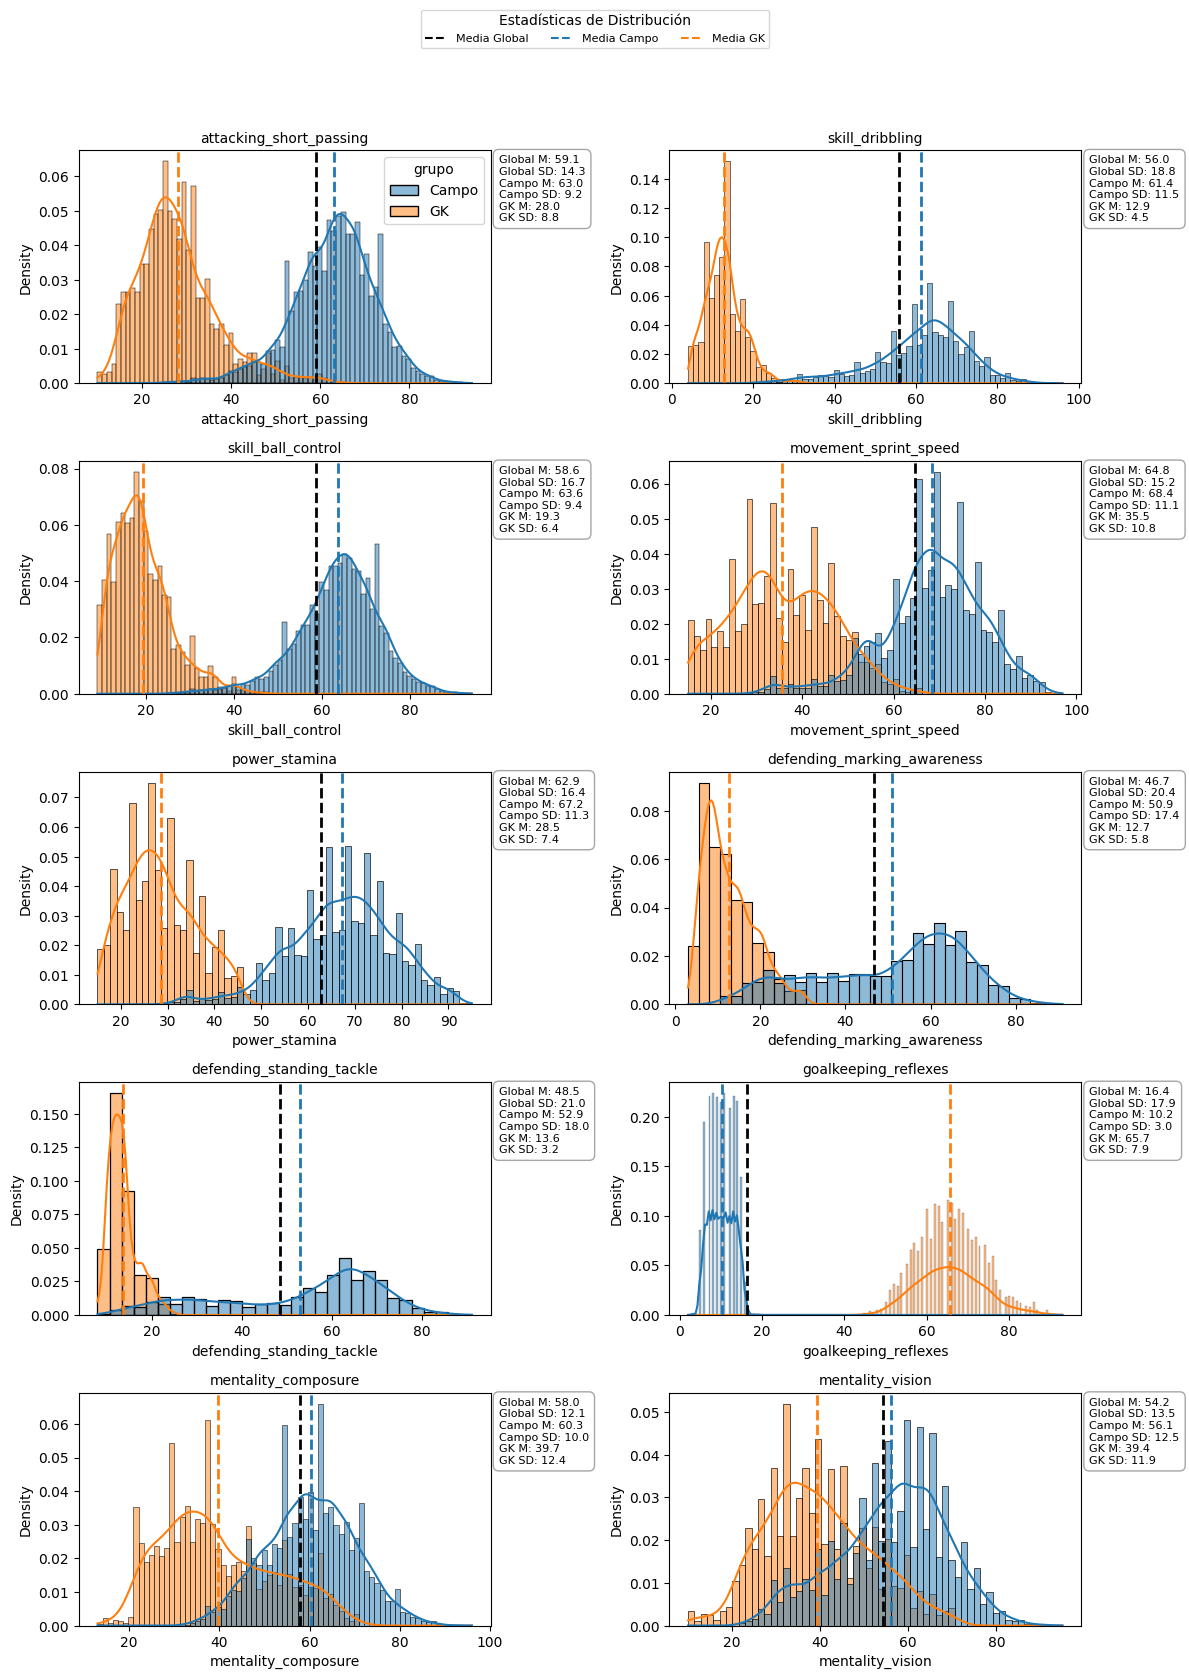

In [ ]:
cols_comparar = [
    'attacking_short_passing', 'skill_dribbling', 'skill_ball_control',
    'movement_sprint_speed', 'power_stamina',
    'defending_marking_awareness', 'defending_standing_tackle',
    'goalkeeping_reflexes','mentality_composure','mentality_vision'
]


df_fc24['grupo'] = df_fc24['player_positions'].apply(lambda x: 'GK' if 'GK' in x else 'Campo')

# Define colors for groups to ensure consistency. Using default seaborn palette colors for distinction.
grupo_colors = {'Campo': '#1f77b4', 'GK': '#ff7f0e', "Global": "#000000"} # Blue and Orange from default matplotlib/seaborn

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
axes = axes.flatten()

LINE_STYLE= "--"
LINE_WIDTH= 2

# Custom legend handles for mean and std lines

legend_handles = []
# Global lines
legend_handles.append(Line2D([0], [0], color=grupo_colors["Global"], linestyle= LINE_STYLE, label='Media Global'))

# Campo lines
legend_handles.append(Line2D([0], [0], color=grupo_colors['Campo'], linestyle= LINE_STYLE, label='Media Campo'))

# GK lines
legend_handles.append(Line2D([0], [0], color=grupo_colors['GK'], linestyle= LINE_STYLE, label='Media GK'))



for ax, col in zip(axes, cols_comparar):
    sns.histplot(
        data=df_fc24, x=col, hue='grupo', kde=True,
        stat='density', common_norm=False,
        ax=ax, legend=(col == cols_comparar[0]),
        palette=grupo_colors # Use the defined palette
    )

    # Calculate statistics
    global_mean = df_fc24[col].mean()
    global_std = df_fc24[col].std()
    campo_mean = df_fc24_campo[col].mean()
    campo_std = df_fc24_campo[col].std()
    gk_mean = df_fc24_gk[col].mean()
    gk_std = df_fc24_gk[col].std()

    # Set the main title for the subplot
    ax.set_title(col, fontsize=10)

    # Create the text for the statistics box
    stats_text = (
        f"Global M: {global_mean:.1f}\n"
        f"Global SD: {global_std:.1f}\n"
        f"Campo M: {campo_mean:.1f}\n"
        f"Campo SD: {campo_std:.1f}\n"
        f"GK M: {gk_mean:.1f}\n"
        f"GK SD: {gk_std:.1f}"
    )
    # Add the text box to the subplot
    # Using transform=ax.transAxes places text relative to the axes (0,0 bottom-left, 1,1 top-right)
    # bbox creates a box around the text
    ax.text(1.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7, ec='gray'))

    # Add lines for mean
    ax.axvline(global_mean, color=grupo_colors["Global"], linestyle= LINE_STYLE, linewidth= LINE_WIDTH)

    ax.axvline(campo_mean, color=grupo_colors['Campo'], linestyle= LINE_STYLE, linewidth= LINE_WIDTH)

    ax.axvline(gk_mean, color=grupo_colors['GK'], linestyle= LINE_STYLE, linewidth= LINE_WIDTH)

# Add the figure-wide legend
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, title='Estadísticas de Distribución', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for the main legend
plt.show()

**Observacion I**

Notemos que hay dos patrones de
asimetría opuestos y consistentes con la composición del plantel:

- En los atributos orientados a jugadores de campo (por ejemplo
  `defending_marking_awareness`con media 46.67, mediana 52.0), la **media queda por debajo de
  la mediana**, ya que la mayoría de los jugadores tiene valores medios/altos, pero la minoría de
  arqueros (con valores bajos en estos atributos) arrastra la media hacia abajo, generando
  una cola hacia la izquierda.
- En los atributos de arquero (`goalkeeping_diving`, `handling`, `kicking`, `positioning`,
  `reflexes` con media ≈16, mediana ≈11, máximo hasta 90), ocurre el fenómeno inverso: la
  **media queda por encima de la mediana**. Acá la mayoría de los jugadores (de campo) tienen
  valores bajos, y es la minoría de arqueros (~2045) la que empuja la media hacia arriba con
  valores altos, generando una cola hacia la derecha.

Esto solo nos confirma lo que ya sospechábamos, el tener en consideración a los arqueros puede distorsionar los análisis, porque se está
promediando sobre dos poblaciones con perfiles de habilidad estructuralmente distintos.

**Observacion II**

Al visualizar la
distribución de `defending_marking_awareness` y `defending_standing_tackle` separando por
color a arqueros y jugadores de campo, se observó que la curva
correspondiente a **jugadores de campo es bimodal**, es decir que presenta dos modas (una baja, ~15-20, y otra alta, ~60-65). Esto sugiere que, incluso después de excluir arqueros, el grupo "campo"
sigue conteniendo subpoblaciones heterogéneas en cuanto a su perfil defensivo (por ejemplo,
delanteros vs. defensores), lo cual sirve como indicio visual a confirmar más adelante en el
clustering del Punto 4.

**Observacion III.**

Si comparamos la media y desvío estándar entre `df_fc24_campo` y `df_fc24_gk` por separado, se repite un patrón: el desvío estándar del grupo de campo es notablemente mayor
que el del grupo de arqueros en casi todos los atributos de campo (por ejemplo,
`skill_dribbling`: std 11.52 en campo vs. 4.52 en arqueros; `defending_standing_tackle`: std
18.04 vs. 3.19; `power_stamina`: std 11.28 vs. 7.43).
Esto es así, ya que los arqueros entrenan y son evaluados sobre un conjunto acotado y específico de habilidades
propias de su rol único, mientras que "jugador de campo" agrupa una variedad mucho más amplia
de posiciones y perfiles (desde un delantero puro hasta un defensor central), lo que conlleva una mayor heterogeneidad estadística.

Un caso distinto es el de los atributos `mentality_composure` y `mentality_vision`, donde la separación visual entre arqueros y jugadores de campo es **mucho menos marcada** que en el resto
de los atributos, con distribuciones que se superponen considerablemente. Como son atributos más ligados a la toma de decisiones y el control emocional bajo presión, no dependen tan directamente del rol específico en la cancha.


Ahora, analicemos algunas de las variables categóricas

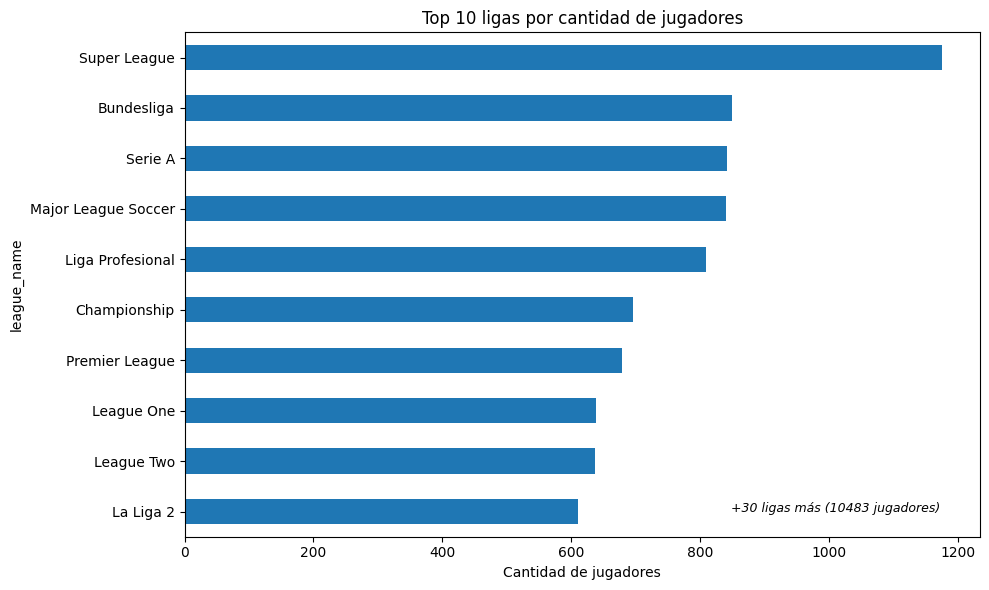

In [ ]:
liga_counts = df_fc24['league_name'].value_counts().sort_values(ascending=False)
top10_liga = liga_counts.head(10)
n_otras_ligas = len(liga_counts) - 10
jugadores_otras_ligas = liga_counts.iloc[10:].sum()

fig, ax = plt.subplots(figsize=(10, 6))
top10_liga.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Cantidad de jugadores')
ax.set_title('Top 10 ligas por cantidad de jugadores')
ax.text(0.95, 0.05, f'+{n_otras_ligas} ligas más ({jugadores_otras_ligas} jugadores)',
        transform=ax.transAxes, ha='right', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

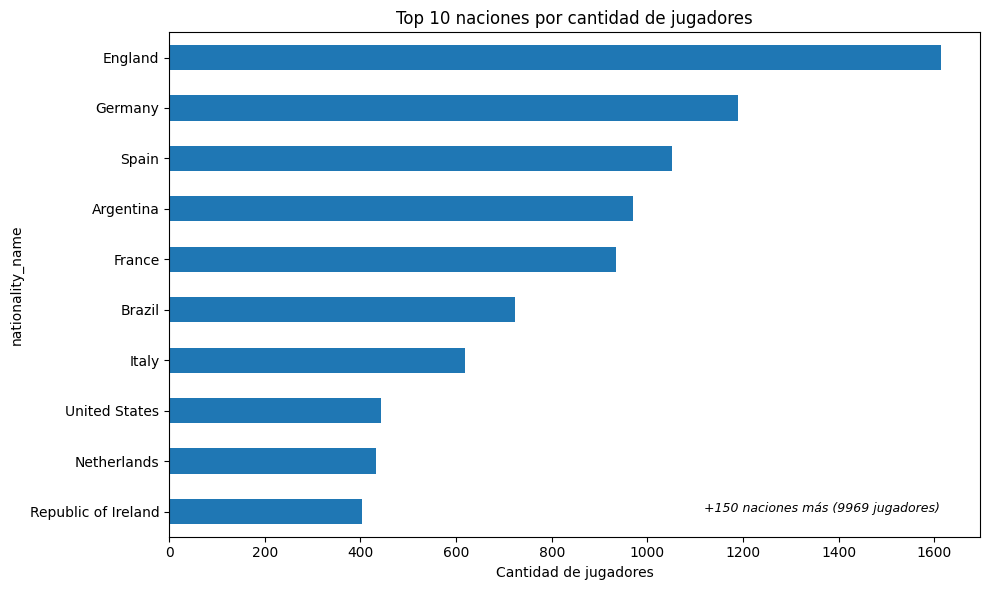

In [ ]:
nation_counts = df_fc24['nationality_name'].value_counts().sort_values(ascending=False)
top10_nation = nation_counts.head(10)
n_otras_nation = len(nation_counts) - 10
jugadores_otras_nation = nation_counts.iloc[10:].sum()

fig, ax = plt.subplots(figsize=(10, 6))
top10_nation.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Cantidad de jugadores')
ax.set_title('Top 10 naciones por cantidad de jugadores')
ax.text(0.95, 0.05, f'+{n_otras_nation} naciones más ({jugadores_otras_nation} jugadores)',
        transform=ax.transAxes, ha='right', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribución de pie preferido')

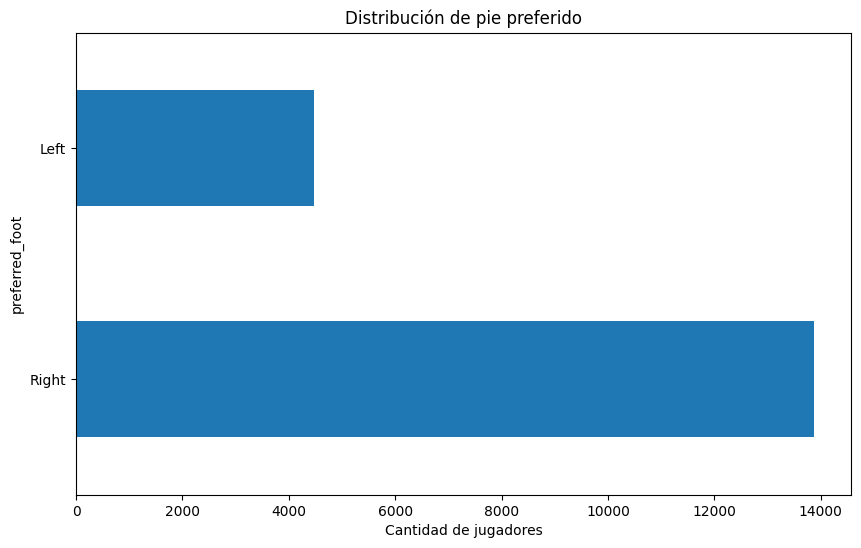

In [ ]:
favorite_foot = df_fc24['preferred_foot'].value_counts()
favorite_foot.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Cantidad de jugadores')
plt.title('Distribución de pie preferido')

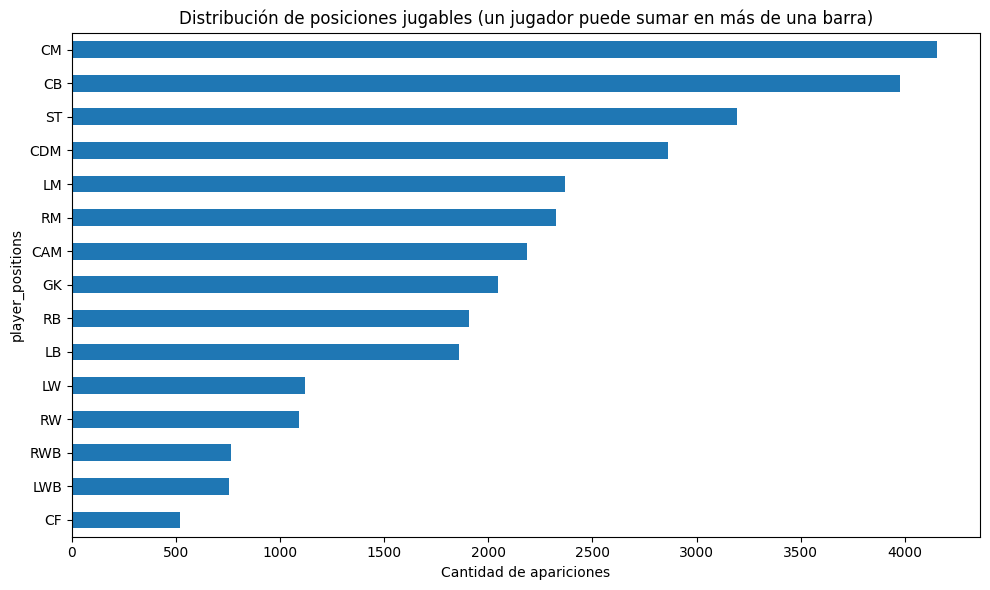

Total de jugadores: 18350
Total de apariciones posición-jugador: 31120


In [ ]:
posiciones_todas = df_fc24['player_positions'].str.split(', ').explode()
posiciones_counts = posiciones_todas.value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
posiciones_counts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Cantidad de apariciones')
ax.set_title('Distribución de posiciones jugables (un jugador puede sumar en más de una barra)')
plt.tight_layout()
plt.show()

print(f"Total de jugadores: {df_fc24.shape[0]}")
print(f"Total de apariciones posición-jugador: {posiciones_todas.shape[0]}")

## Respuesta

### Dimensiones y tipos de variables

El dataset original (`male_players.csv`) contiene **180021 filas × 109 columnas**, con la
siguiente composición de tipos: `float64(20)`, `int64(43)`, `object(46)`.

Un primer análisis reveló que este tamaño no corresponde a 180021 jugadores distintos: las
columnas `fifa_version`, `fifa_update` y `update_as_of` muestran que el archivo agrupa el
histórico de múltiples ediciones del juego (FIFA 15 a EA Sports FC 24) en un solo archivo,
por lo que cada jugador real puede aparecer repetido una vez por cada edición en la que fue
incluido.

Dado que el objetivo del trabajo es encontrar jugadores intercambiables **en la actualidad**
(no tiene sentido reemplazar a Messi 2015 por Messi 2024), y no analizar la evolución histórica de los jugadores, se
decidió filtrar el dataset a la edición más reciente disponible (en este caso, fifa 24). Se
verificó además la columna `fifa_update` (que registra actualizaciones de stats dentro de una
misma edición) y se confirmó que para la versión 24 solo existe el valor `2.0`, por lo que no fue necesario un filtro adicional por esta columna.

Así, obtuvimos el **`df_fc24`, con 18350 jugadores × 109 columnas.**

**Duplicados:** sobre `df_fc24` no se encontraron duplicados por `player_id`, pero se detectaron 21 casos de `long_name` repetidos, pero al
comparar la fecha de nacimiento (`dob`) de cada par se confirmó que corresponden a jugadores reales distintos con nombres coincidentes (homónimos), no a errores de carga de datos.

---

###  Selección de columnas relevantes

Como el objetivo del trabajo es agrupar jugadores por sus **habilidades futbolísticas**, se conservan para el análisis las variables que describen capacidades del jugador dentro de la cancha, y se descartan las
que aportan identificación, contexto contractual/de mercado, o metadata sin relación directa con el desempeño futbolístico.

**Columnas descartadas** Si bien nos referimos a ellas con este adjetivo, lo cierto es que el dataset nunca se toca, solo no se usan como input del clustering, aunque algunas —posición, liga, nacionalidad— sí se exploran más abajo en la distribución de categóricas:

`player_id`, `player_url`, `fifa_version`, `fifa_update`, `update_as_of`, `short_name`,
`long_name`, `potential`, `value_eur`, `wage_eur`, `age`, `dob`, `height_cm`, `weight_kg`,
`club_position`, `club_team_id`, `club_name`, `league_id`, `league_name`, `league_level`,
`club_jersey_number`, `club_loaned_from`, `club_joined_date`,
`club_contract_valid_until_year`, `nationality_id`, `nationality_name`, `nation_team_id`,
`nation_position`, `nation_jersey_number`, `international_reputation`, `work_rate`,
`body_type`, `real_face`, `release_clause_eur`, `player_tags`, `player_traits`.

**Columnas conservadas**, agrupadas en dos familias de habilidades:

- **Generales (6):** `pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic` —
  promedios ponderados que resumen cada área del juego.
- **Detalladas (~35):** columnas con prefijo `attacking_*`, `skill_*`, `movement_*`,
  `power_*`, `mentality_*`, `defending_*`, `goalkeeping_*` — los atributos granulares
  (0-99) a partir de los cuales EA calcula los 6 resúmenes anteriores.

Usar ambos sets simultáneamente introduciría redundancia (los generales son función directa de los detallados), por lo que se evaluará en el Punto 4 cuál de los dos produce mejores resultados de clustering, en vez de decidirlo a priori.

También se conservan las 27 columnas de **rating por posición** (`ls`, `st`, `rs`, ...,
`gk`), a diferencia de `club_position`/`nation_position` (descartadas): estas últimas solo
indican la posición habitual del jugador en su club/selección y tienen alta proporción de
faltantes (no todos los jugadores tienen club o selección activa), mientras que las columnas
de rating por posición dan, para cada jugador, un puntaje estimado en las 27 posiciones de
la cancha — información más rica y completa para medir equivalencia entre jugadores.

---

###  Missing values

Sobre `df_fc24` (18350 × 109), estas son las columnas con algún valor faltante:

| Columna | No nulos | % nulos |
|---|---|---|
| nation_team_id / nation_position / nation_jersey_number | 780 | 95.75% |
| club_loaned_from | 1180 | 93.57% |
| player_tags | 1252 | 93.18% |
| goalkeeping_speed | 2045 | 88.86% |
| player_traits | 8609 | 53.08% |
| pace / shooting / passing / dribbling / defending / physic | 16305 | 11.14% |
| release_clause_eur | 17070 | 6.98% |
| club_joined_date | 17083 | 6.90% |
| value_eur | 18250 | 0.54% |
| club_name / league_name / league_id / league_level / club_position / club_jersey_number / club_contract_valid_until_year / club_team_id / wage_eur | 18263 | 0.47% |

La gran mayoría de estos faltantes caen en columnas ya descartadas para el clustering, y son
esperables por motivos de dominio: solo una fracción de los jugadores integra su selección
nacional en un momento dado (explica `nation_*`), pocos están a préstamo (`club_loaned_from`),
no todos los clubes/jugadores tienen datos de mercado valuados (`value_eur`, `club_name`,
`league_name`, etc.), y `player_tags`/`player_traits` son metadata opcional.

El caso relevante para el objetivo del trabajo es el de **`pace`/`shooting`/`passing`/
`dribbling`/`defending`/`physic`** (2045 faltantes) y **`goalkeeping_speed`** (16305
faltantes, el complemento exacto). Se verificó que ambos patrones de missing corresponden
exactamente a la posición de arquero (`player_positions == 'GK'`). A un arquero no se le
calculan los 6 atributos generales de jugador de campo, y solo a los arqueros se les calcula
`goalkeeping_speed`.

Dado que imputar estos valores con 0 introduciría un sesgo conceptual (0 implica "no tiene la
habilidad", cuando en realidad "no aplica medirla" para ese rol), y que desde el punto de
vista futbolístico un arquero se reemplaza por otro arquero — no tiene sentido compararlo con
jugadores de campo en atributos como `pace` o `shooting` —, se optó por **excluir a los arqueros del análisis principal**:

- `df_fc24_gk`: 2045 arqueros (guardado aparte, como posible análisis secundario)
- `df_fc24_campo`: 16305 jugadores de campo, sin valores faltantes en las columnas de
  habilidad relevantes → base sobre la que continúa el análisis.

---

###  Estadística descriptiva de variables numéricas

Se calcularon las medidas de tendencia central y dispersión para el conjunto
de atributos de habilidad —generales y detalladas— sobre `df_fc24` completo (109 columnas, incluye arqueros). Todos estos atributos están definidos en una escala de 0 a 99.


A partir de lo explicado en Observaciones I II y III, reafirmamos la decisión ya tomada en la sección de missing values de excluir a los arqueros del análisis principal de
clustering. No es solo que sus datos generales (`pace`, `shooting`, etc.) estén ausentes, sino
que incluso en los atributos detallados (sin faltantes) arqueros y jugadores de campo se
comportan como poblaciones estadísticamente distintas.

---

###  Distribución de variables categóricas

Se analizó la distribución de posición, liga y nacionalidad sobre `df_fc24` completo (18350
jugadores, arqueros incluidos), ya que estas variables describen composición general del
plantel y no dependen de la decisión de exclusión de arqueros tomada para el clustering.
Adicionalmente se incluyó `preferred_foot` por resultar de interés para la caracterización de
los jugadores.

**Posición (`player_positions`).** Cada jugador puede tener más de una posición jugable (ej.
`"LB, LWB, CM"`), por lo que se optó por contar **todas** las posiciones de cada jugador
(no solo la principal), para capturar la polivalencia del plantel. Esto se implementó
"explotando" la columna, pasando de 18350 filas (una por
jugador) a ~31000 pares posición-jugador. Las posiciones más frecuentes son `CM`, `CB`, `ST`
y `CDM` — roles relativamente genéricos/centrales en los que muchos jugadores versátiles se
declaran aptos —, mientras que posiciones más específicas como `CF` son las menos comunes.
Como verificación de consistencia, la cantidad de apariciones de `GK` (2045) coincide
exactamente con la cantidad de arqueros identificada previamente, confirmando que en este
dataset la posición de arquero nunca aparece combinada con otra posición de campo.

**Liga (`league_name`) y nacionalidad (`nationality_name`).** Ambas variables presentan una
cantidad muy alta de categorías (decenas de ligas, más de 150 nacionalidades), por lo que un
gráfico con todas las categorías resultaría ilegible. Se optó por visualizar el **top 10** de
cada una, indicando en el gráfico la cantidad de categorías y jugadores restantes agrupados
("+N más"). La liga con más jugadores es la Super League (~1176), seguida de Bundesliga,
Serie A y Major League Soccer; sin embargo, las 10 ligas más pobladas concentran menos de la
mitad del total — quedan **+30 ligas más (10483 jugadores)** fuera del top 10.

El mismo patrón, incluso más marcado, se observa en nacionalidad: Inglaterra, Alemania y España
encabezan el ranking, pero quedan **+150 naciones más (9969 jugadores)** fuera del top 10.
Esto indica que la base representa un fútbol geográfica e institucionalmente muy distribuido,
sin concentración fuerte en un puñado de ligas o países.

**Pie preferido (`preferred_foot`).** Variable binaria, con una proporción de
aproximadamente 76% de jugadores diestros y 24% zurdos — consistente con la distribución de
lateralidad conocida en la población futbolística real.

---

### Resumen: dataframes resultantes del Punto 1

Como cierre del punto, la base original quedó organizada en la siguiente jerarquía de
dataframes, que se usará como punto de partida para los puntos siguientes:

- `df_fifa24`: crudo, todas las versiones (180021 × 109)
  - `df_fc24`: solo versión 24 (18350 × 109)
    - `df_fc24_gk`: arqueros (2045 × 109) — análisis secundario, no forma parte del clustering principal
    - `df_fc24_campo`: jugadores de campo (16305 × 109) — base del análisis principal
      - `df_id`: columnas de identificación/contexto (no usadas como input de clustering)
      - `df_hab_generales`: 6 atributos resumen de habilidad
      - `df_hab_detalladas`: ~35 atributos granulares de habilidad
      - `df_posiciones`: 27 columnas de rating por posición (pendiente de limpieza del
        formato `"valor+bonus"` antes de poder usarse como numéricas)

# 2- Evaluación visual e intuitiva de dos a dos variables numéricas por vez.

Sugerencia: hagan los scatterplots de las combinaciones de dos variables que tengan algún sentido para ustedes, porque todas las combinaciones de variables son muchas y no van a poder analizarlas como merecen.

A continuación vamos a comparar de a pares las variables que definimos como habilidades generales, distinguiendo cons dos colores diferentes el pie preferido.

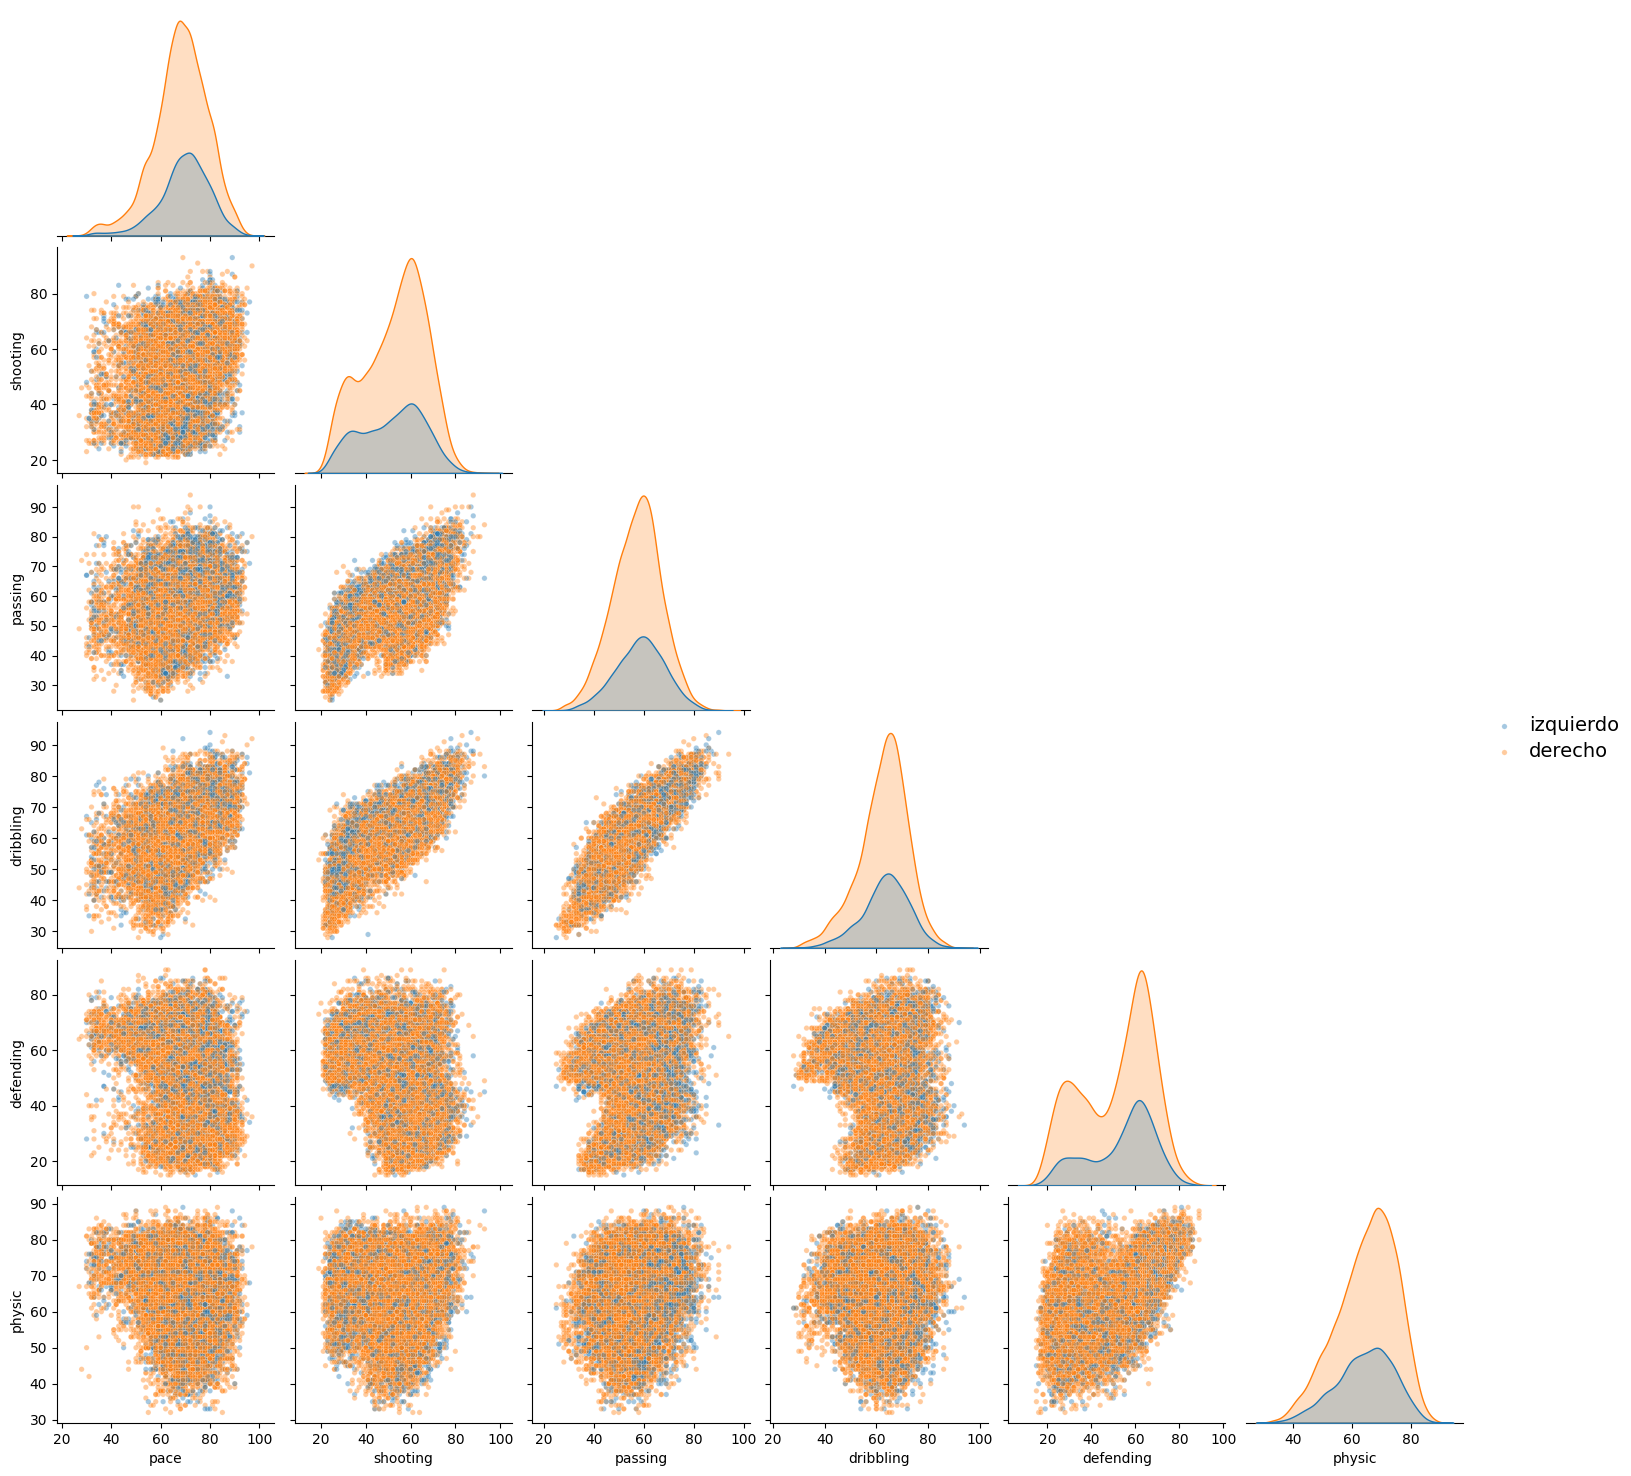

In [ ]:
custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(df_hab_generales, vars=['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic'],
             hue='preferred_foot_enc', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
             palette=custom_palette, corner=True)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

Entre pie izquierdo y derecho no hay diferencias, las distribuciones son extremadamente similares, solo es obvio que hay menos izquierdos que derechos.

El atributo `Pace` parece no tener una relación clara con ninguno de los otros atributos. No es 100% simétrica, tiene una pequeña cola a la izquierda, pero muy leve.
`Shooting` con `passing` y `dribbling` parecen tener una leve relación lineal. Pero lo interesante es que `shooting` parece tener una bimodalidad, mientras que `passing` y `dribbling` no parecen tener ninguna forma de caracterisación entre grupos.
Entre `dribbling` y `passing` la relación es claramente lineal, estan correlacionadas. Y son bastante simétricas (`dribbling` tiene una cola muy leve a la izquierda)
`Defending` tiene una CLARISIMA bimodalidad, esperable, que los jugadores defienden o atacan.
`Physic` tiene una leve cola a la izquierda, tiene una cierta relacion con defending, se pueden observar dos rectas.
Como los puntos están muy superpuestos en estos gráficos vamos a hacer el mismo plot pero con isocontornos, para ver mejor las bimodalidades.

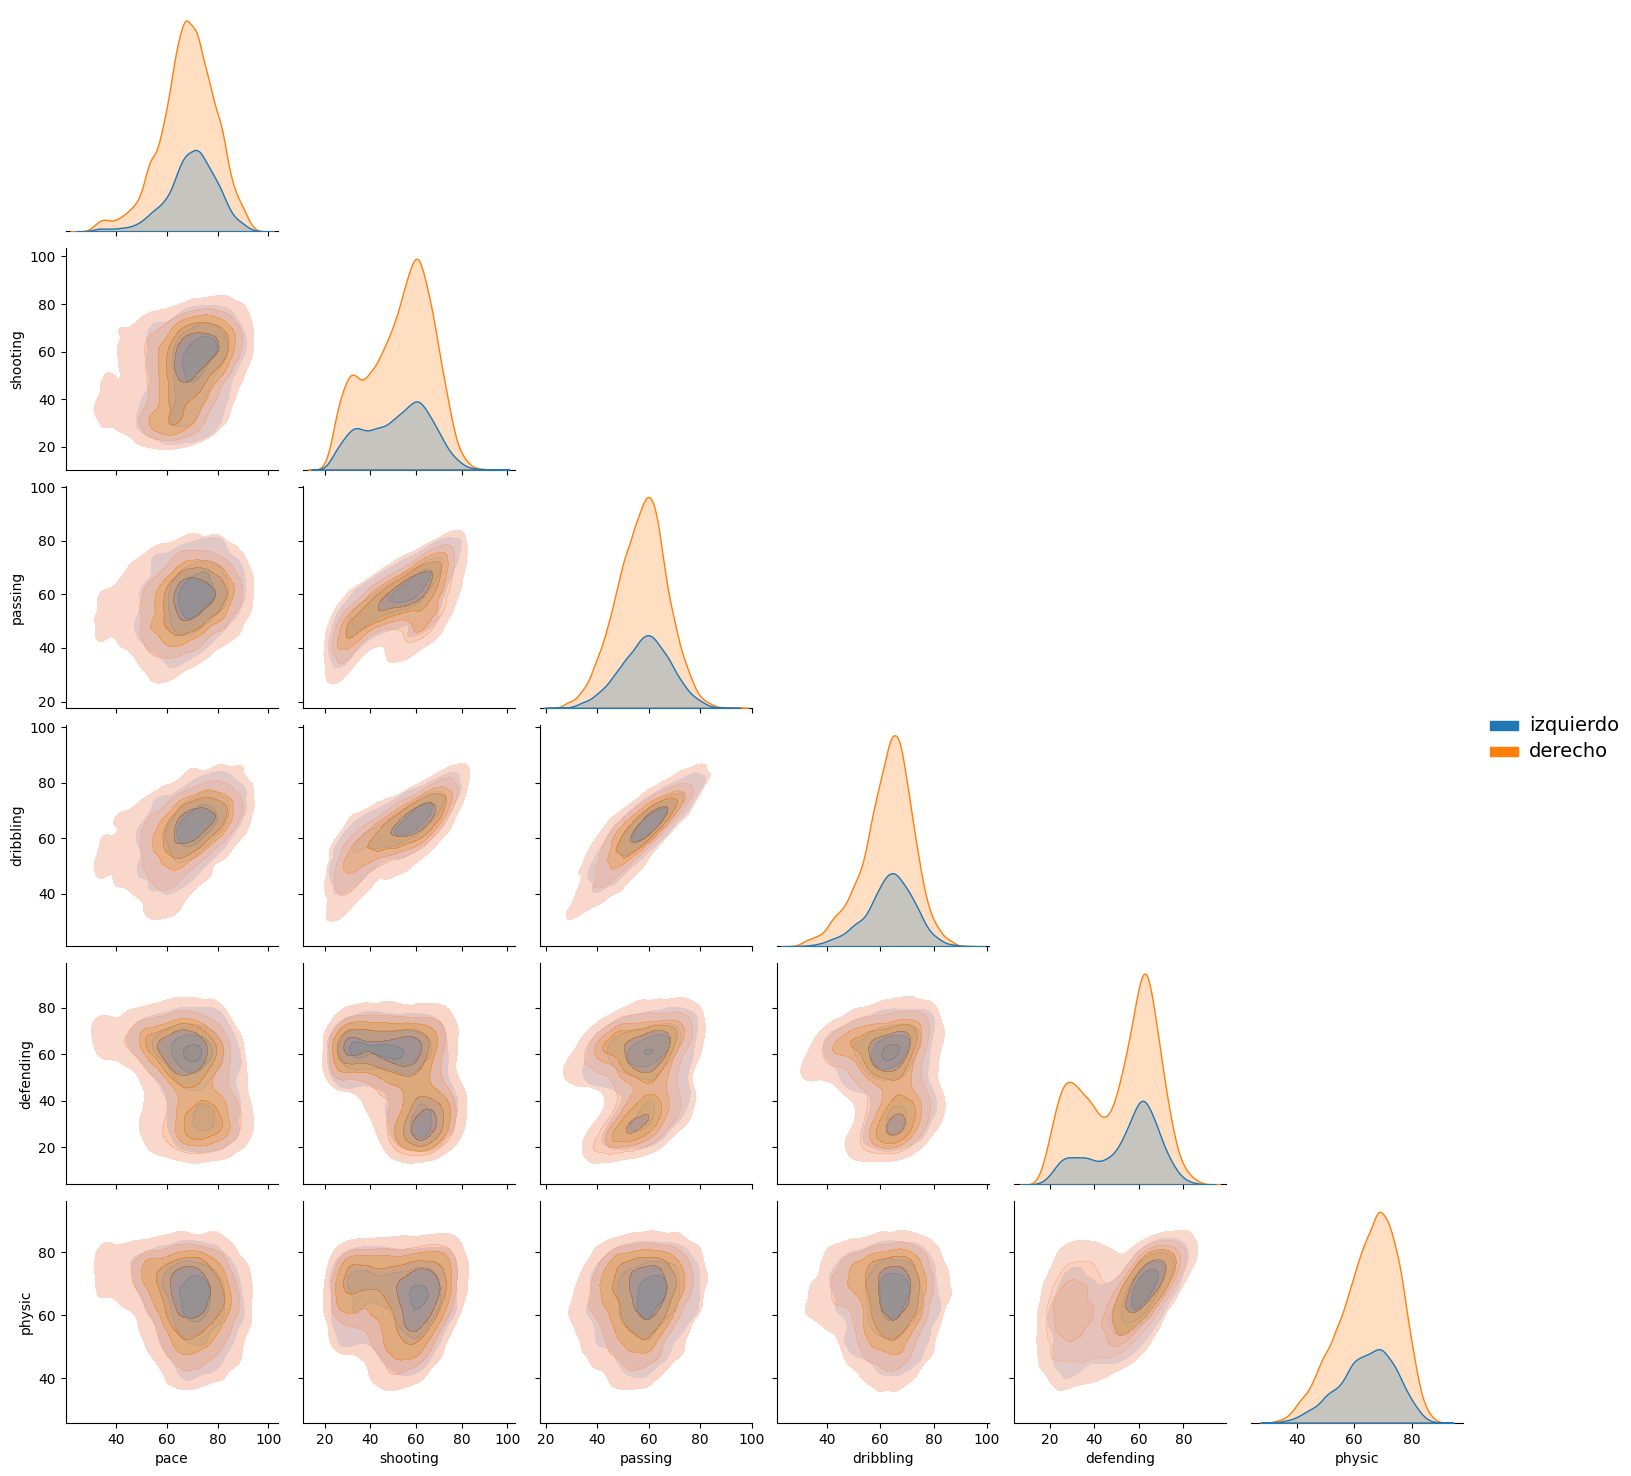

In [ ]:
custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_generales, vars=['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic'], hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    corner=True, palette=custom_palette
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend


plt.show()

De este gráfico se observa que el atributo `defending` separa clases porque tiene bimodalidad con todas las demás habilidades generales.
Inspeccionemos ahora las habilidades detalladas.

In [ ]:
cols_hab_detalladas[10:]

['movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'mentality_composure',
 'defending_marking_awareness',
 'defending_standing_tackle',
 'defending_sliding_tackle',
 'goalkeeping_diving',
 'goalkeeping_handling',
 'goalkeeping_kicking',
 'goalkeeping_positioning',
 'goalkeeping_reflexes',
 'preferred_foot_enc']

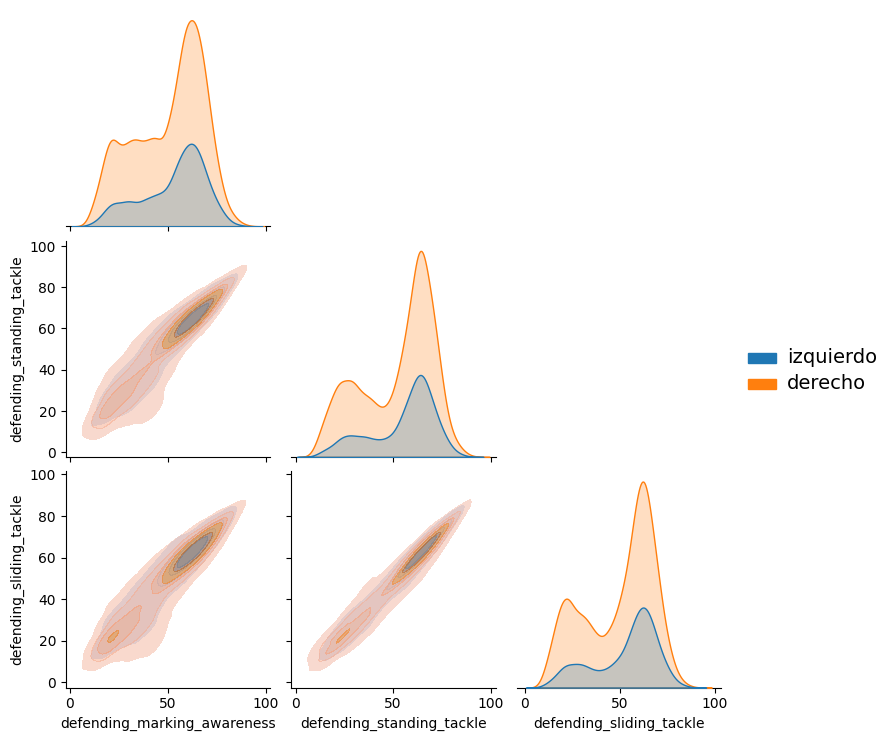

In [ ]:
custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

cols_detalle_muestra = [ 'defending_marking_awareness',
 'defending_standing_tackle',
 'defending_sliding_tackle']

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

Las habilidades específicas de `defending` están todas correlacionadas entre ellas y tienen distribuciones similares, por lo que no aportan mucha información extra.

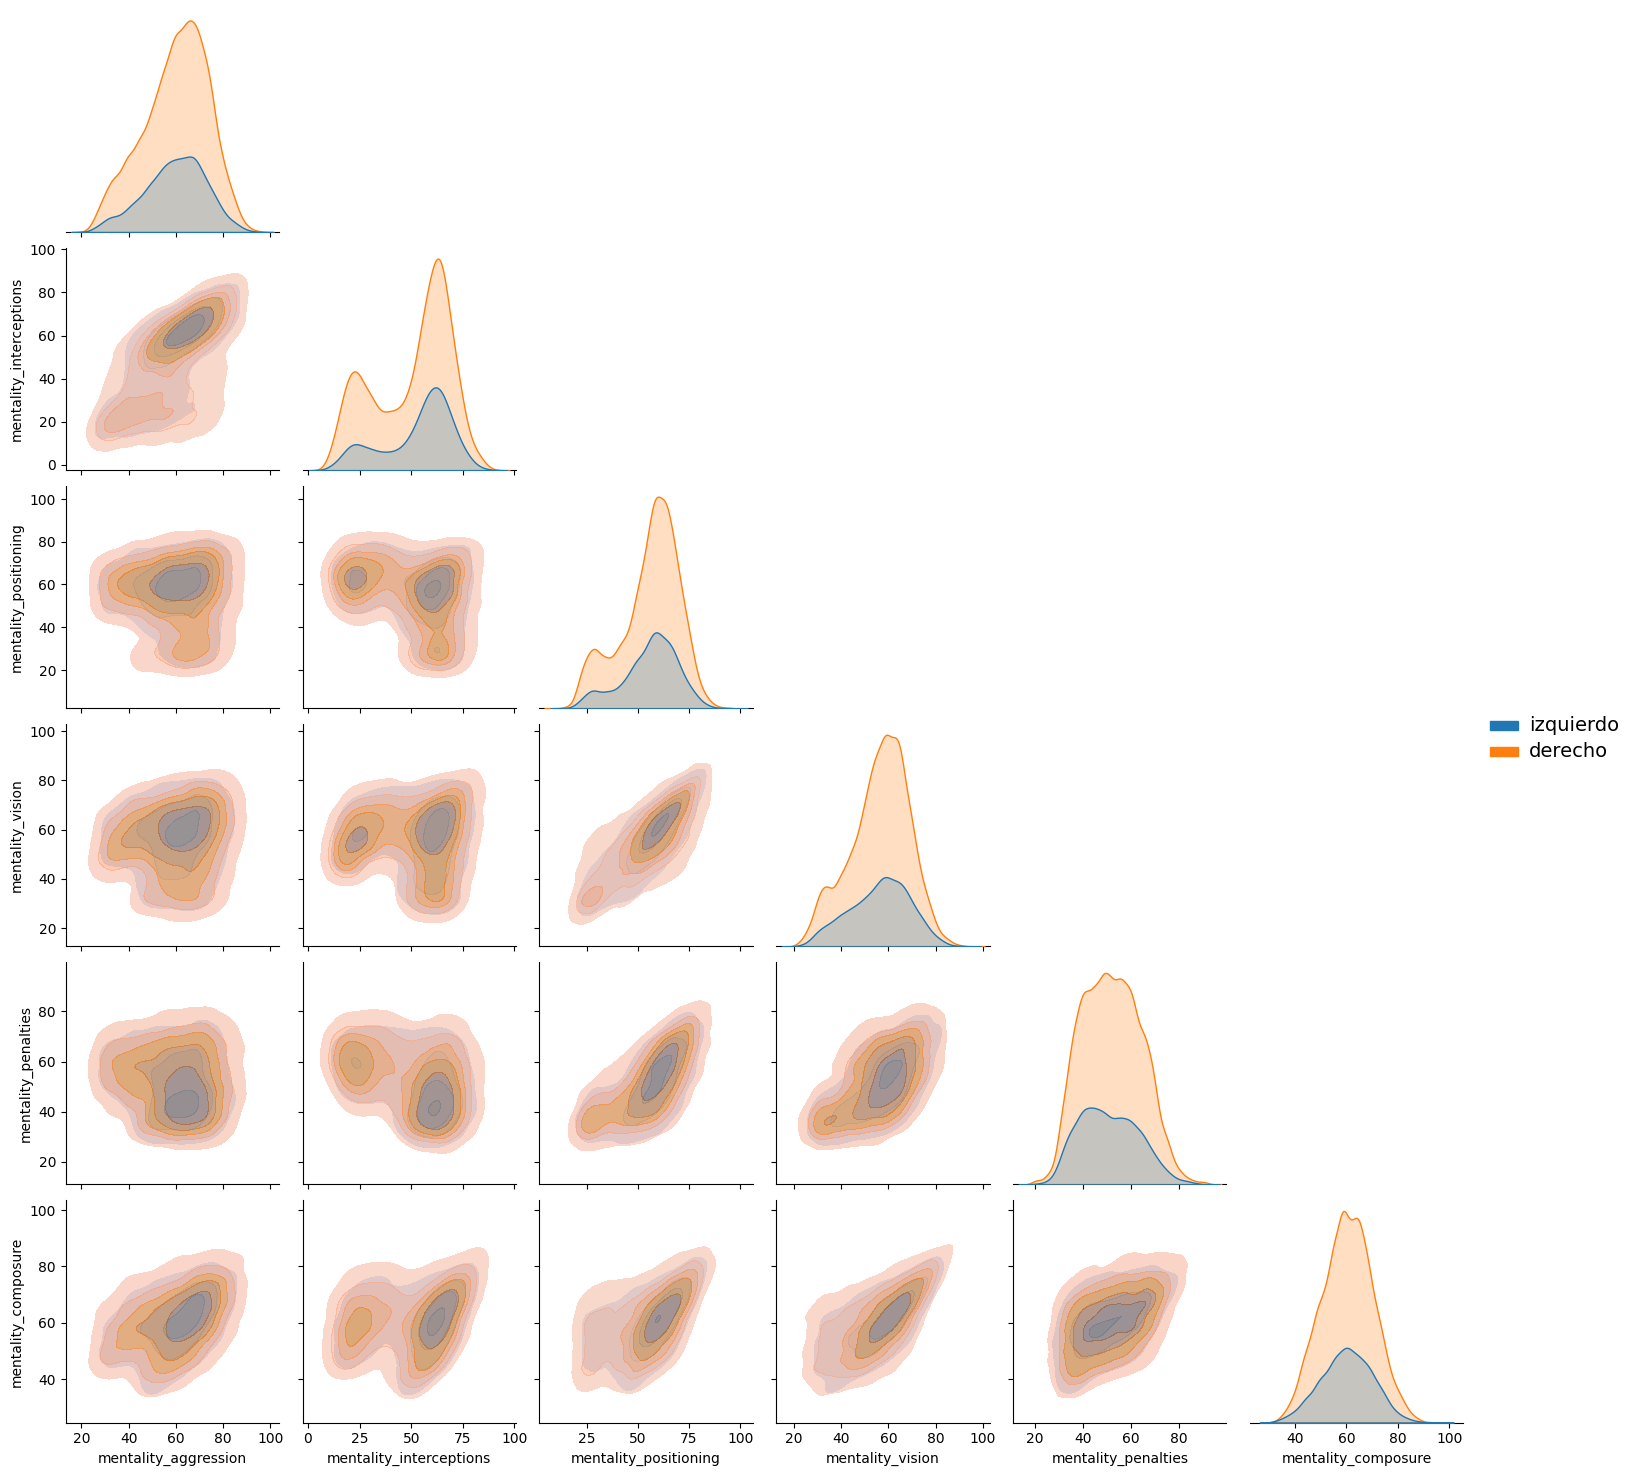

In [ ]:
cols_detalle_muestra = [ 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'mentality_composure']

custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

Viendo las habilidades específicas dentro de `mentality`, vemos que la que tiene una clara bimodalidad con todas es `mentality_interceptions` y en menor medida `mentality_positioning`.

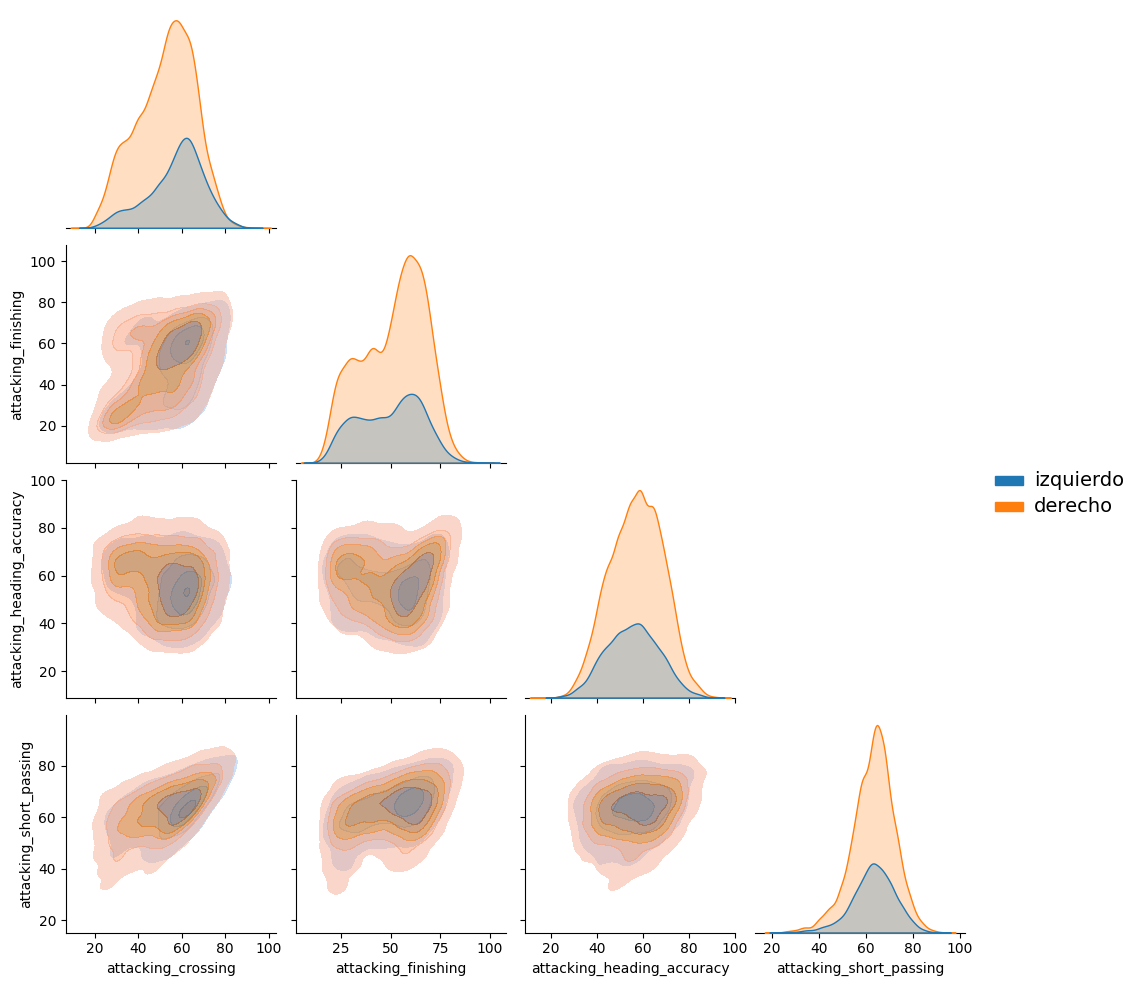

In [ ]:
cols_detalle_muestra = ['attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing']

custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

De la familia del atributo `attacking` la que muestra bimodalidad y mas separa clases es `attacking_finishing`.

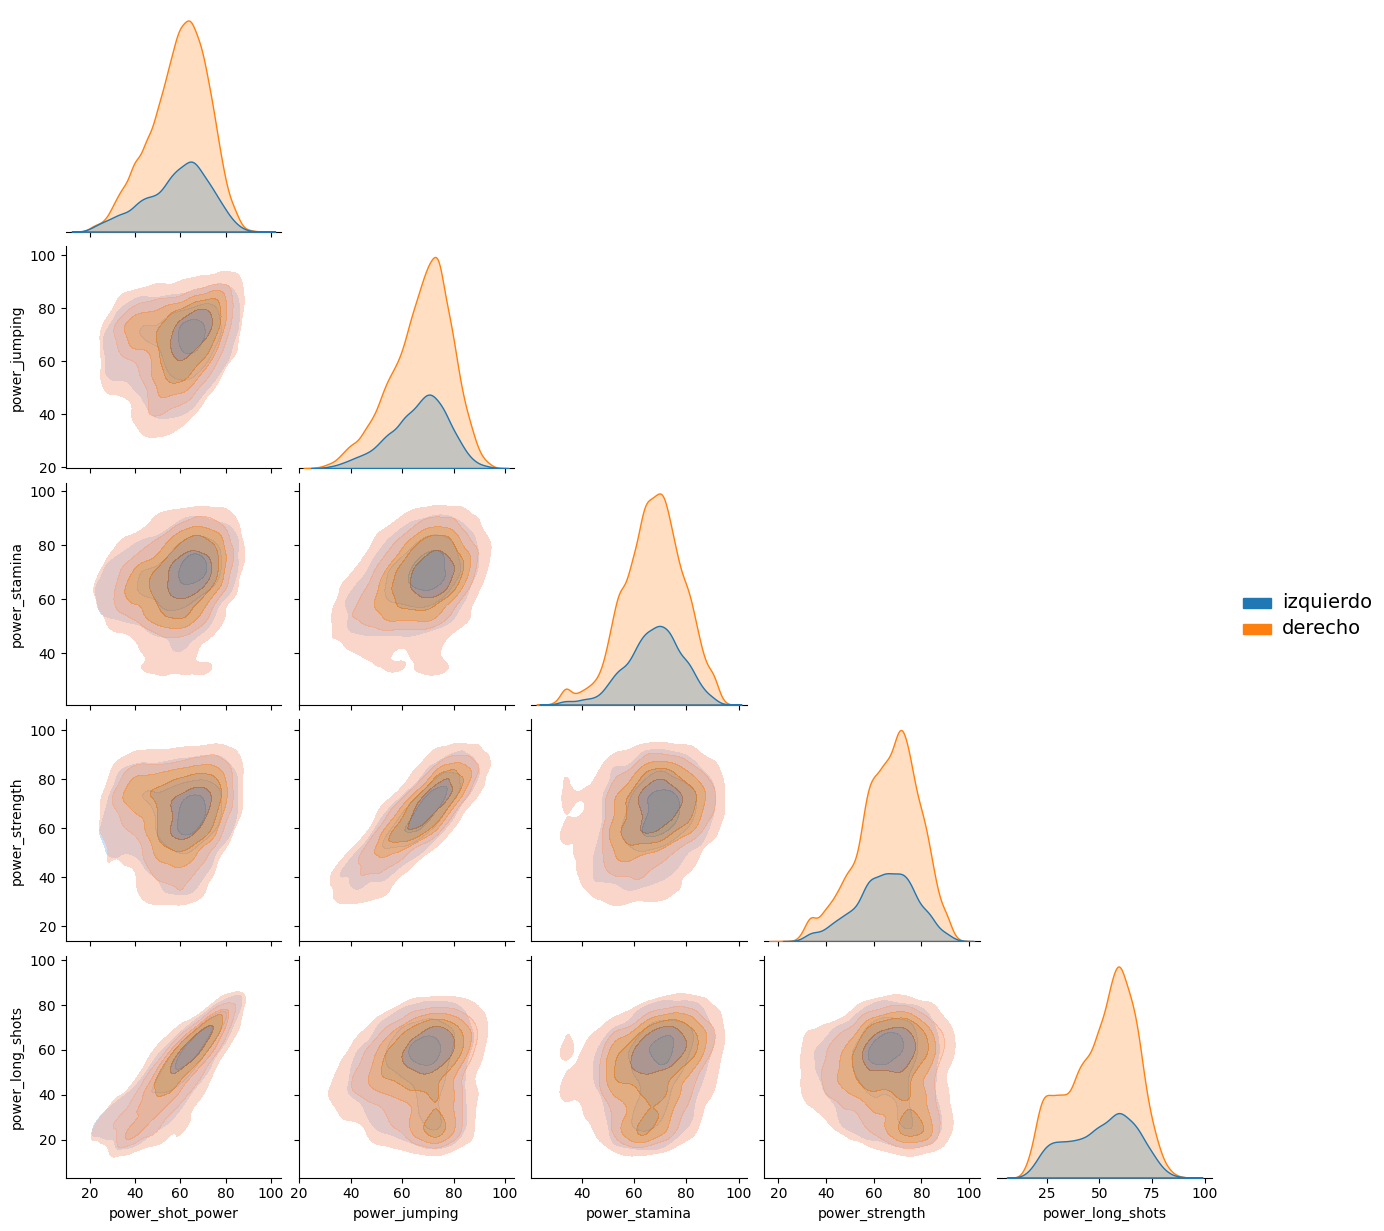

In [ ]:
cols_detalle_muestra = [ 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots']

custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

`power_long_shots` es la única que presenta una clara bimodalidad con respecto a las otras, excepto para `power_shot_power` con la que muestra un cierto grado de correlación lineal.

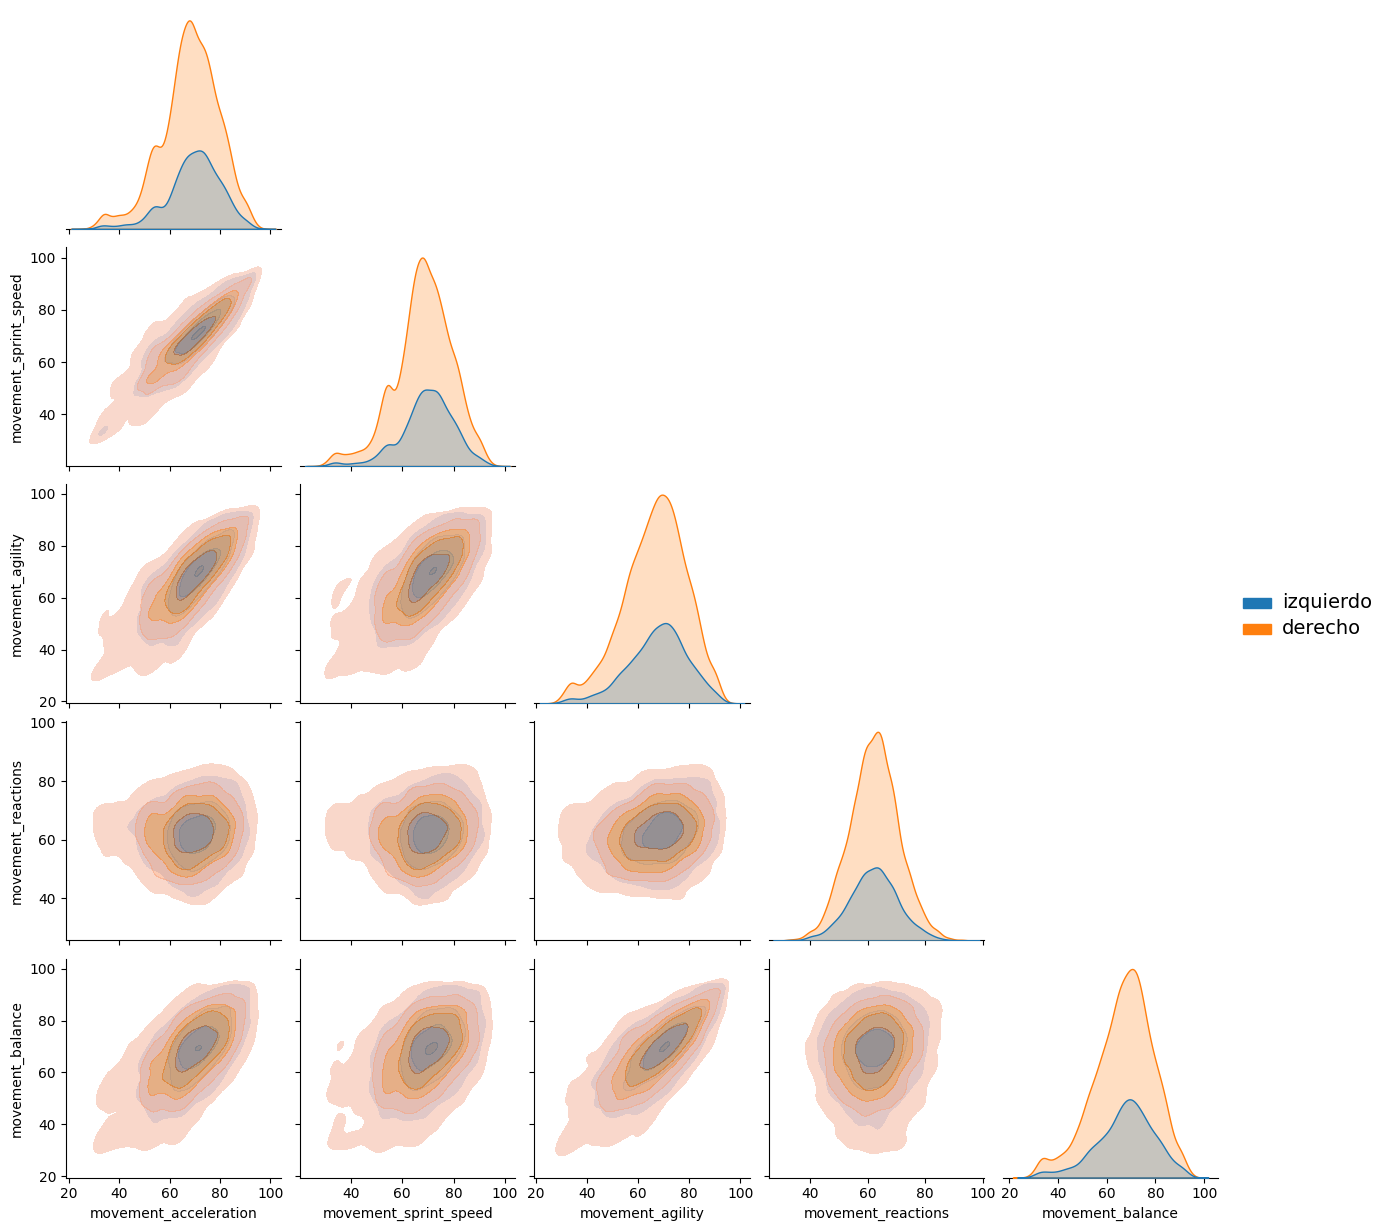

In [ ]:
cols_detalle_muestra = ['movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance']

custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

Esta variable no muestra ninguna separación de clases.

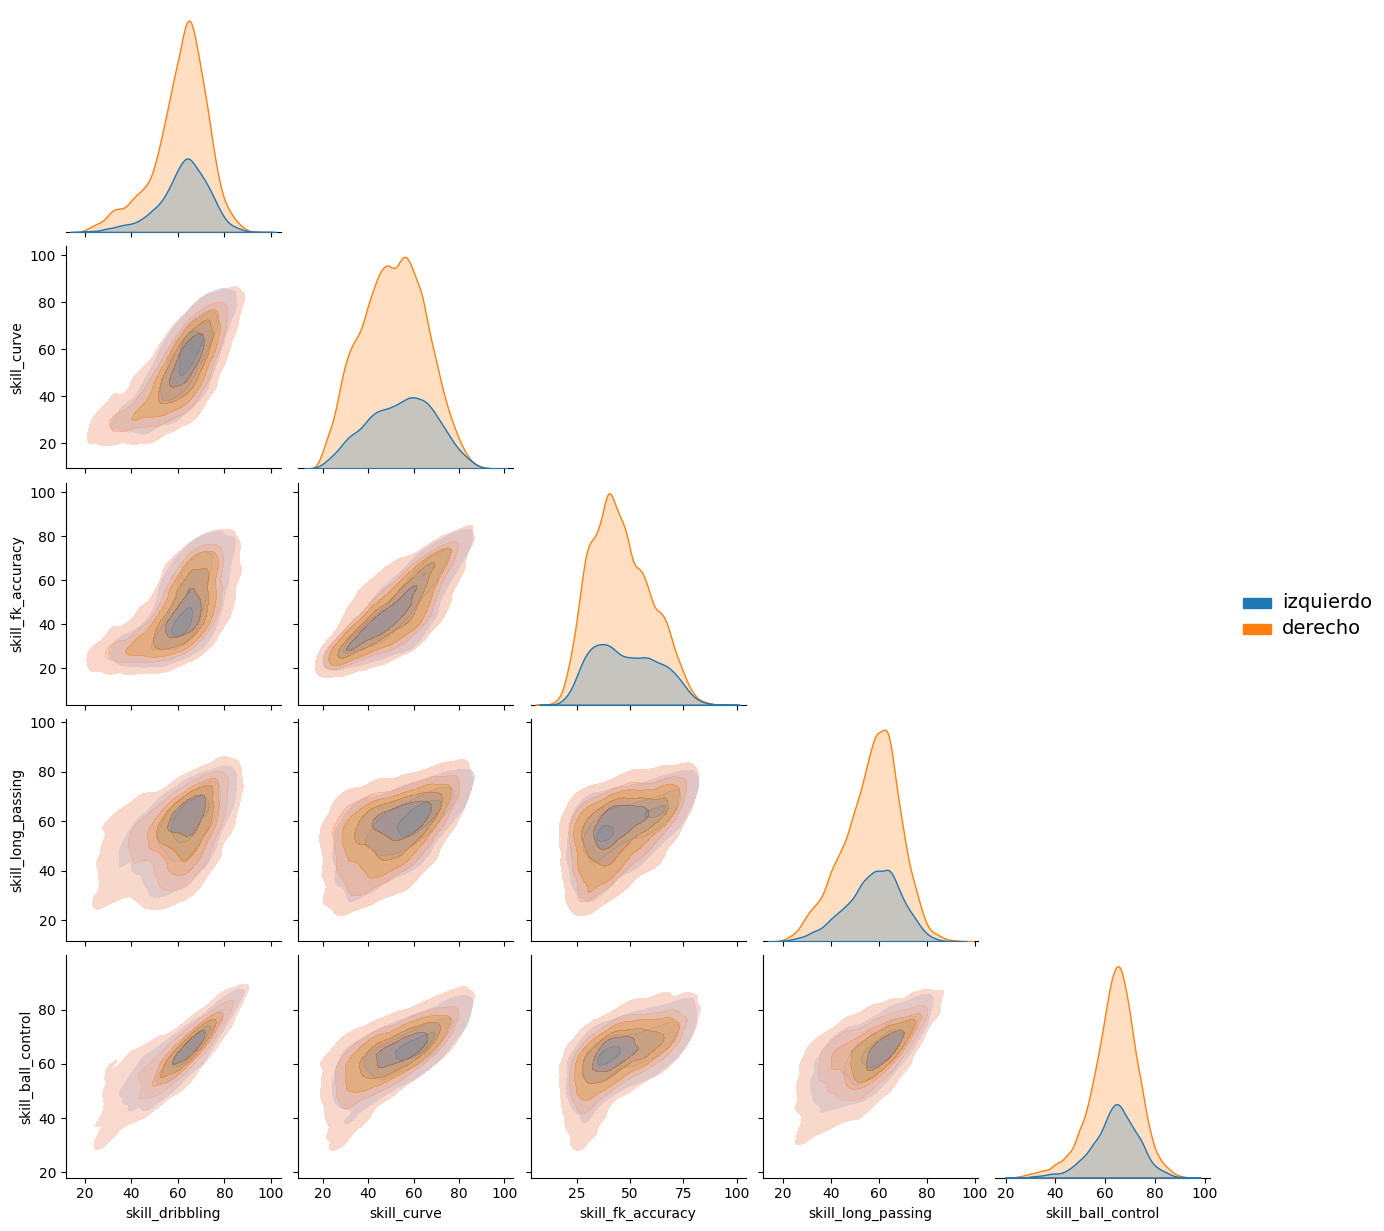

In [ ]:
cols_detalle_muestra = ['skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control']

custom_palette = {0: 'tab:blue', 1: 'tab:orange'}

g = sns.pairplot(
    df_hab_detalladas, vars=cols_detalle_muestra, hue='preferred_foot_enc',
    kind='kde', diag_kind='kde',
    plot_kws={'fill': True, 'alpha': 0.5, 'levels': 6, 'thresh': 0.05},
    palette=custom_palette, corner=True
)

# Access the legend object
legend = g._legend

# Check if the legend exists and modify it
if legend:
    # Remove the legend title 'preferred_foot_enc'
    legend.set_title(None)

    # Map the numerical labels ('0', '1') to the desired text labels (string keys)
    labels_map = {'0': 'izquierdo', '1': 'derecho'}

    # Iterate through the legend text objects and update their labels and font size
    for text_obj in legend.get_texts():
        original_label_str = text_obj.get_text()
        if original_label_str in labels_map:
            text_obj.set_text(labels_map[original_label_str])
        text_obj.set_fontsize(14) # Set font size for each text object in the legend

plt.show()

De estas habilidades de la familia `skill` la única que muestra una leve bimodalidad es `skill_fk_accuracy`.

### ----- Selección final de atributos para clustering (Punto 4) -----

Tras la exploración visual del Punto 2 (pairplots con KDE, separados por
`preferred_foot_enc`), se decidió construir una selección **mixta** de atributos:
en vez de usar exclusivamente las 6 habilidades "generales" (donde solo `defending`
mostraba separación clara y el resto se diluía) o el set completo de ~35 atributos
"detallados" (con alta redundancia interna entre atributos de una misma familia), se
inspeccionó familia por familia para identificar qué atributos puntuales conservan
señal discriminante real.

**Hallazgos por familia:**

- **`defending`** (marking_awareness, standing_tackle, sliding_tackle): las tres
  columnas están casi perfectamente correlacionadas entre sí y con el atributo general
  `defending`. Se descartaron las tres específicas ya que usarlas junto con `defending`
  pesaría el eje defensivo varias veces sin aportar información nueva.
- **`mentality`**: `mentality_interceptions` (y, muy cerca, `mentality_positioning`)
  son las únicas con bimodalidad clara; `mentality_vision`/`aggression` muestran una
  separación más tenue, y `mentality_penalties`/`composure` son esencialmente
  unimodales. Se eligió `mentality_interceptions` como complemento de `defending` ya que mide una faceta distinta (lectura/anticipación) de la misma capacidad defensiva.
- **`attacking`**: `attacking_finishing` es la única con separación clara dentro de
  la familia; `crossing`, `heading_accuracy` y `short_passing` son comparativamente
  unimodales.
- **`power`**: `power_long_shots` es la única con bimodalidad visible; el resto
  (`shot_power`, `jumping`, `strength`) son unimodales con cola. Elegida como
  complemento de `attacking_finishing` en el eje ofensivo (potencia de remate de
  media/larga distancia vs. definición de área).
- **`skill`**: separación más moderada en general; `skill_fk_accuracy` fue elegida en lugar
del `dribbling` general, este habla más de si sos "buen" o "mal" gambeteador sin matices adicionales.
 Mientras que la precisión en tiros libres aporta una faceta técnica más específica
 (asociada a mediocampistas ofensivos/delanteros con buena pegada), con una
 separación más moderada que `defending` o `mentality_interceptions`, pero conceptualmente distinta
 de las demás columnas elegidas
- **`movement`**: ninguna columna de esta familia mostró separación relevante por lo que la descartamos.

**Selección final (6 atributos):**

| Atributo | Familia | Eje futbolístico que representa | Motivo |
|---|---|---|---|
| `defending` | General | Defensa (marca/tackle) | Resume con un solo número las 3 columnas de `defending`, casi redundantes entre sí |
| `mentality_interceptions` | Detallada | Defensa (lectura/anticipación) | La más bimodal de `mentality`; complementa a `defending` con una faceta distinta |
| `attacking_finishing` | Detallada | Ataque (definición) | La única de `attacking` con separación clara |
| `power_long_shots` | Detallada | Ataque (potencia de remate) | Bimodal, a diferencia del resto de `power` |
| `skill_fk_accuracy` | Detallada | Técnica / pelota parada | Faceta ofensiva/técnica específica no cubierta por las otras; separación más moderada, incluida por el eje que representa, no por bimodalidad |
| `preferred_foot_enc` | Engineered | Lateralidad | No mide nivel de habilidad, sino un rasgo relevante para validar reemplazos |

Con esto se llega a una selección de **6 dimensiones** (5 continuas + 1 binaria):
compacta, manejable para clustering, y que cubre defensa (dos facetas distintas),
ataque (dos facetas distintas), técnica y lateralidad — en vez de depender de un único
atributo agregado (`defending`) para toda la separación, como ocurría con las 6
generales.

**Pregunta abierta a resolver en el Punto 5:** no es evidente todavía si esta
combinación de atributos termina separando jugadores por *nivel general* (buenos vs.
malos) o por *rol/posición* (jugadores igualmente buenos, pero en facetas distintas del
juego) — que es la distinción relevante para el objetivo del trabajo (equivalencia de
reemplazo). Esto solo se puede evaluar mirando los perfiles de los clusters resultantes.

# 3- Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué ?


Sí, se aplicó estandarización antes de clusterizar. Todas las técnicas consideradas
(K-Means, HDBSCAN) construyen sus agrupamientos a partir de distancias entre
observaciones, y si las variables quedan en su escala original, un atributo de rango
amplio (ej. `defending`, 0-99) domina el cálculo de distancia frente a uno binario como
`preferred_foot_enc` (0/1), un artefacto de escala, no una decisión real sobre qué
atributo importa más para definir equivalencia entre jugadores.

In [ ]:
cols_clustering = ['defending',
                   'mentality_interceptions',
                   'attacking_finishing',
                   'power_long_shots',
                   'skill_fk_accuracy',
                   'preferred_foot_enc'
                   ]

X = df_fc24_campo[cols_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### ----- Normalización -----

Se utilizó `StandardScaler` (z-score: resta la media, divide por el desvío), que deja
todas las variables en media 0 y desvío 1, sin acotarlas a un rango fijo. Se aplicó
`fit_transform` sobre la totalidad de columnas utilizadas para el clustering, `cols_clustering`.

Decisión de diseño a documentar: `preferred_foot_enc` se escaló junto con las 6
habilidades continuas, por simplicidad. Implica que, tras estandarizar, el pie
preferido pesa en la distancia de forma comparable a cualquier habilidad. Una
alternativa sería tratarlo aparte, pero se priorizó la opción simple dado que no hay evidencia de que deba pesar más o menos que el resto.

# 4- Aplicación de clustering



Encontrar grupos de jugadores con habilidades equivalentes, por ejemplo, jugadores que podrían intercambiarse en el caso de una lesión o cuando un jugador está cansado. Para esto utilice como mínimo dos técnicas de clustering: por ejemplo k-medias,MinShift, DBSCAN, mezcla de Gaussianas y/o Single linkage y otras jerárquicas. Justifiquen por qué eligen los diferentes hiper-parámetros que se puedan elegir según el método: número de clusters, medida de distancia, criterio de aglomeración… Utilicen al menos una métrica cuantitativa de evaluación de clustering (por ejemplo, coeficiente de silhouette, índice de rand ajustado, u otra que consideren pertinente) para comparar los resultados obtenidos con las distintas técnicas y/o configuraciones de hiperparámetros probadas, y justifiquen a partir de esas métricas cuál configuración/método les resultó más adecuado.

### ----- Elección de técnicas de clustering -----

Se decidió utilizar **K-Means** y **HDBSCAN**, dos algoritmos de *clustering* que siguen caminos opuestos al determinar la forma de los datos. Esta elección fue para contrastar dos formas distintas encontrar grupos en los datos.

**K-Means:**

- *Beneficios*: es simple, rápido incluso con muchas observaciones, y
  da resultados fáciles de interpretar (en este caso cada cluster queda representado por un
  centroide, un "jugador promedio" del grupo, natural para describir perfiles). Al fijar
  `n_clusters=k` de antemano, obliga a una partición completa: todo jugador queda
  asignado a algún grupo, sin dejar casos sin clasificar. Esto es algo que buscamos, ya que acá el objetivo es tener, para cualquier jugador del plantel, un conjunto de reemplazos
  posibles.
- *Cuidados*: asume que los clusters son de forma aproximadamente esférica/convexa y de
  tamaño similar. Si la estructura real de los datos es muy alargada o de densidades muy
  dispares, K-Means puede "cortar" mal los grupos. Es sensible a la escala de las
  variables (de ahí la necesidad del `StandardScaler` del Punto 3) y a la inicialización
  de los centroides (mitigado usando `n_init=10`, que prueba varias inicializaciones y se
  queda con la mejor). Requiere fijar `k` de antemano, no lo "descubre" solo: hay que
  elegirlo con un criterio externo (inercia/silhouette).

**HDBSCAN:**

- *Beneficios*: no requiere especificar la cantidad de clusters de antemano, los
  encuentra a partir de zonas de alta densidad en el espacio de atributos. Puede detectar
  clusters de forma irregular (no asume esfericidad como K-Means) y de tamaños/densidades
  distintos entre sí, una mejora sobre el DBSCAN clásico, que usa un único $\epsilon$
global y sufre cuando los clusters tienen densidades muy diferentes. Identifica explícitamente  puntos "ruido" (etiqueta `-1`), jugadores "raros" que no encajan claramente en ningún  grupo, información en sí misma relevante (podrían ser jugadores con perfiles poco  frecuentes, difíciles de reemplazar).
- *Cuidados*: es computacionalmente más costoso y la cantidad de clusters resultante depende fuertemente de
  `min_cluster_size`/`min_samples`, y no hay garantía de que todos los jugadores queden
  agrupados (a diferencia de K-Means, algunos pueden quedar como ruido). No produce
  "centroides" interpretables de la misma manera directa que K-Means. Con parámetros mal
  elegidos, puede colapsar a muy pocos clusters grandes o, en el extremo opuesto, dejar una gran cantidad de jugadores sin clasificar.

**Por qué esta combinación en particular:** al ser paradigmas distintos (particional
contra densidad), una coincidencia entre lo que encuentra K-Means y lo que encuentra
HDBSCAN sobre el mismo set de atributos es evidencia más fuerte de que la estructura
encontrada es real y no un artefacto de un único método. Una discrepancia, en cambio,
obliga a entender por qué difieren antes de elegir cuál resultado usar para el análisis
cualitativo del Punto 5.


### K-Means

In [ ]:
inertias, siluetas = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels))

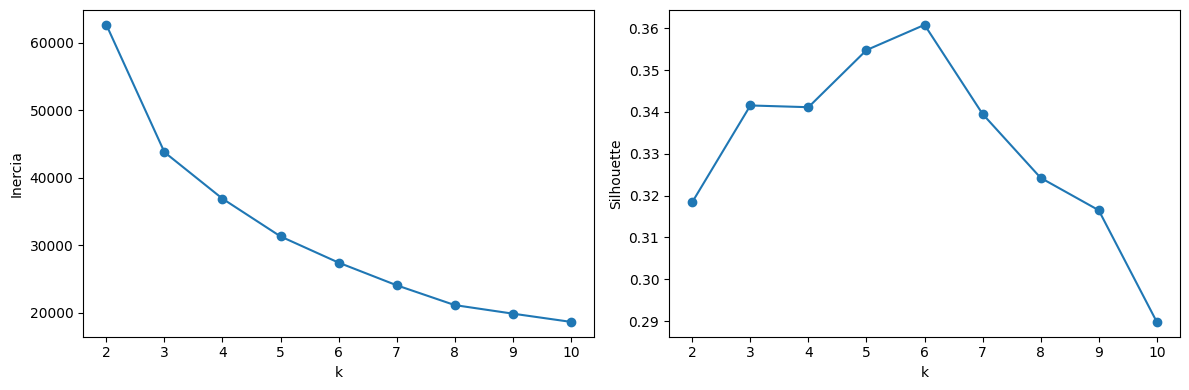

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 11), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(range(2, 11), siluetas, marker='o')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

Se evaluaron valores de k entre 2 y 10 clusters sobre el set final de 6 atributos
(`defending`, `mentality_interceptions`, `attacking_finishing`, `power_long_shots`,
`skill_fk_accuracy`, `preferred_foot_enc`, estandarizados), usando dos criterios
complementarios:

La inercia mide qué tan compactos y unidos están los puntos dentro de cada grupo y lo que buscamos es que en su gráfica se forme un codo. Este muestra un quiebre único y marcado: es el número ideal de grupos, porque añadir más ya no mejora mucho la unión de los datos.

Pero por lo general el codo no es, por sí solo, un criterio determinante. En este caso vemos que la curva es suave, sin ningún corte o codo claro, por lo que se utilizó Tambien otro criterio para definir el número óptimo de clusters, Silhouette.

Este coeficiente de silueta mide qué tan bien encaja cada punto en su grupo en comparación con los demás grupos cercanos. Evalúa tanto la cohesión (cuánto se parece un punto a los de su mismo grupo) como la separación (cuánto se aleja de los grupos vecinos). Un puntaje de silueta alto (de 0 a 1) indica que los grupos están bien separados y definidos con claridad.

Aquí este criterio nos brinda un análisis más claro, con `k = 6` el silhouette es máximo (0.361), de manera que tomamos a este como el k óptimo.

In [ ]:
km_final = KMeans(n_clusters=6, n_init=10, random_state=42)
labels = km_final.fit_predict(X_scaled)

### HDBSCAN

La busqueda del mejor número de K para HDBSCAN la probamos con una busqueda de hiperparámetros, variando primero `min_cluster_size`, el menor número de muestras posibles para formar un grupo , y `min_samples`, el número de vecínos necesarios para que un punto sea núcleo del grupo, mientras más grande más estricto es el algorítmo y encuentra más ruido. Luego también se variará `cluster_selection_method` entre `eom` (default) y `leaf`. Aquí `eom` busca la "estabilidad", prioriza menos y más grandes grupos minimizando el , mientras que `leaf` no le da tanta importancia a esta "estabilidad" de manera que tiende a seccionar los datos en más grupos de menor tamaño, pero viene con un costo, es posible encontrarse con más ruido.

In [ ]:

resultados = []
for min_cluster_size, min_samples in itertools.product([50, 100, 150, 200, 300], [5, 10, 15, 20, 30]):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
    labels_temp = clusterer.fit_predict(X_scaled)

    mask = labels_temp != -1
    n_clusters = len(set(labels_temp[mask]))
    frac_ruido = (labels_temp == -1).mean()

    sil = silhouette_score(X_scaled[mask], labels_temp[mask]) if n_clusters >= 2 else None

    resultados.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'frac_ruido': round(frac_ruido, 3),
        'silhouette': round(sil, 3) if sil is not None else None
    })

df_resultados = pd.DataFrame(resultados).sort_values('silhouette', ascending=False)
df_resultados.head(15)

,min_cluster_size,min_samples,n_clusters,frac_ruido,silhouette
0,50,5,2,0.0,0.24
1,50,10,2,0.0,0.24
2,50,15,2,0.0,0.24
3,50,20,2,0.0,0.24
4,50,30,2,0.0,0.24
5,100,5,2,0.0,0.24
6,100,10,2,0.0,0.24
7,100,15,2,0.0,0.24
8,100,20,2,0.0,0.24
9,100,30,2,0.0,0.24


### ----- Búsqueda de hiperparámetros — HDBSCAN (primera pasada) -----

Se probó una grilla de `min_cluster_size` (50-300) y `min_samples` (5-30) con el método
de selección de clusters por default (`cluster_selection_method='eom'`). El resultado fue idéntico en las
25 combinaciones: **2 clusters, 0% de ruido, silhouette = 0.24**. Esto indica que existe
una única partición de densidad extremadamente persistente en este espacio de 6
atributos, tan dominante que ningún ajuste de estos dos hiperparámetros logra que HDBSCAN
encuentre una subestructura más fina. Ahora para continuar explorando se estudia `cluster_selection_method='leaf'`.

In [ ]:
resultados = []
for min_cluster_size, min_samples, method in itertools.product(
    [50, 100, 200], [5, 15, 30], ['eom', 'leaf']
):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method=method
    )
    labels_temp = clusterer.fit_predict(X_scaled)

    mask = labels_temp != -1
    n_clusters = len(set(labels_temp[mask]))
    frac_ruido = (labels_temp == -1).mean()
    sil = silhouette_score(X_scaled[mask], labels_temp[mask]) if n_clusters >= 2 else None

    resultados.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'method': method,
        'n_clusters': n_clusters,
        'frac_ruido': round(frac_ruido, 3),
        'silhouette': round(sil, 3) if sil is not None else None
    })

df_resultados = pd.DataFrame(resultados).sort_values('silhouette', ascending=False)
df_resultados

,min_cluster_size,min_samples,method,n_clusters,frac_ruido,silhouette
15,200,15,leaf,5,0.773,0.581
5,50,30,leaf,6,0.762,0.552
11,100,30,leaf,6,0.762,0.552
3,50,15,leaf,6,0.763,0.547
9,100,15,leaf,6,0.763,0.547
13,200,5,leaf,6,0.757,0.539
7,100,5,leaf,6,0.757,0.539
1,50,5,leaf,7,0.766,0.517
17,200,30,leaf,5,0.695,0.419
0,50,5,eom,2,0.000,0.240


### ----- Búsqueda de hiperparámetros — HDBSCAN (extensión: leaf) -----

Con `leaf` sí aparece variación: se alcanzan hasta 5-7 clusters y silhouettes de hasta
0.581 — pero a costa de clasificar como "ruido" entre el 69.5% y el 77.3% de los
jugadores. Ese silhouette más alto no es útil, ya que se calcula únicamente sobre el subconjunto de
jugadores que si se incluyen en algún cluster (~23-30% del total), excluyendo a la mayoría.
Para el objetivo del trabajo, encontrar un reemplazo posible para *cualquier* jugador
del plantel, una configuración que deja sin clasificar a más de 7 de cada 10 jugadores
no es utilizable, sin importar cuán alto sea su silhouette.

### ----- Comparación final y elección del método -----

| Método | Configuración | Cobertura | Silhouette |
|---|---|---|---|
| K-Means | k=6 | 100% | **0.361** |
| HDBSCAN | `eom` (cualquier min_cluster_size/min_samples probado) | 100% | 0.24 |
| HDBSCAN | `leaf` (mejor config: min_cluster_size=200, min_samples=15) | 22.7% | 0.581 (no comparable, descartado) |

Comparando configuraciones que separan al 100% de los jugadores clasificados **K-Means con k=6 obtiene el
silhouette más alto (0.361)**, superando a la mejor configuración utilizable de HDBSCAN
(0.24). Las configuraciones de HDBSCAN con mayor silhouette nominal (`leaf`) se
descartaron por dejar sin clasificar a la mayoría de los jugadores.

**Se selecciona K-Means (k=6) como configuración final de clustering**, sobre la cual se
realiza el análisis cualitativo del Punto 5.

# 5- Análisis cualitativo de los clusters encontrados.

¿Qué hay en cada cluster? ¿Son efectivamente equivalentes los jugadores de un cluster, es decir, podrían cumplir el mismo rol en un equipo? Si se trata de clusters heterogéneos, ¿por qué razón pueden haber sido agrupadas las jugadoras del cluster? ¿Qué motiva las diferencias en tamaño?

Veamos que hay en cada cluster teniendo en cuenta los atributos elegidos.

In [ ]:
df_perfil = df_fc24_campo.copy()
df_perfil['cluster'] = labels

In [ ]:
cols_perfil = ['defending', 'mentality_interceptions', 'attacking_finishing',
               'power_long_shots', 'skill_fk_accuracy', 'preferred_foot_enc']

df_perfil.groupby('cluster')[cols_perfil].mean().round(1)

,defending,mentality_interceptions,attacking_finishing,power_long_shots,skill_fk_accuracy,preferred_foot_enc
cluster,,,,,,
0,31.6,27.4,63.6,58.4,48.3,1.0
1,61.8,61.3,33.2,34.1,33.5,1.0
2,61.7,62.9,57.1,61.4,55.7,1.0
3,61.4,60.8,33.4,34.8,34.8,0.0
4,61.6,62.6,56.2,62.0,60.5,0.0
5,32.9,28.9,63.2,59.2,51.6,0.0


De esta table vemos que el cluster `0` y el `5` tienen baja puntuación en defensa y mentalidad de intercepción, mientras que sus puntajes en ataque, potencia y precisión son altos, indicando que puede referirse a jugadores delanteros con preferencia de pie derecho e izquierdo, respectivamente. Los cluster `2` y `4` tienen puntajes altos tanto en defensa como en ataque, por lo que pueden ser jugadores de medio campo. Y finalmente los grupos `1` y `3` tienen puntaje alto en defensa pero no en ataque, lo que sugiere que son defensores.
Veamos a continuación los clusters teniendo en cuenta las posiciones.

In [ ]:
df_perfil['posicion_principal'] = df_perfil['player_positions'].str.split(', ').str[0]
pd.crosstab(df_perfil['cluster'], df_perfil['posicion_principal'])

posicion_principal,CAM,CB,CDM,CF,CM,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
cluster,,,,,,,,,,,,,,
0,462,0,0,78,82,1,527,292,0,1,431,219,0,2006
1,21,2164,483,0,291,63,13,7,13,766,39,7,180,0
2,297,278,846,21,1401,32,127,46,15,410,190,58,115,84
3,6,698,64,0,53,622,24,3,132,5,10,4,3,0
4,94,120,126,6,355,442,93,13,104,4,64,33,3,13
5,169,0,0,26,22,2,173,55,1,0,210,133,0,354


Vemos que el cluster `0` tiene en su mayoría jugadores `ST`, y en menor medida pero en grandes proporciones `LM`, `CAM` y `RM`. Al igual que el cluster `5` pero con números mas pequeños. El cluster `2` tiene una gran cantidad de `CM` y le siguen `CDM`, en cambio el `4` tiene mas `LB` que `CM`. El `1` tiene gran cantidad de `CB` y le sigue `RB`, mientras que el `3` también tiene gran cantidad de `CB` pero casi igual número de `LB`.
Miremos las posiciones en la canc

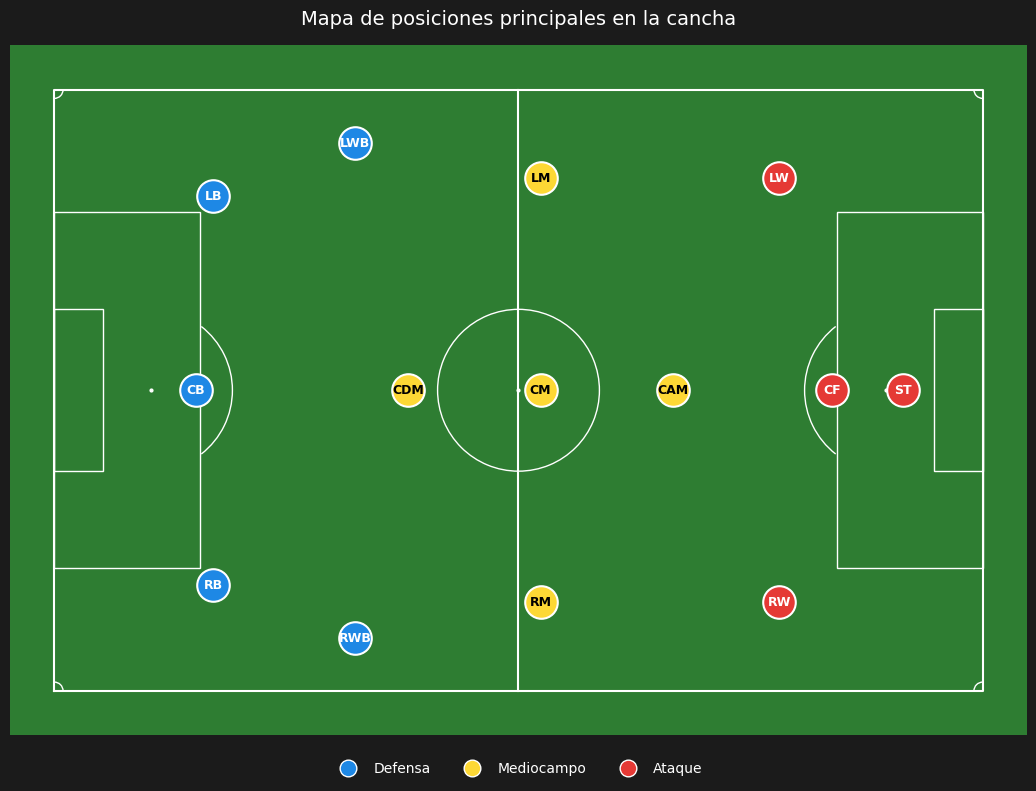

In [ ]:


# ---------------------------------------------------------------------
# 1. Dimensiones de la cancha (en metros), ataque de izquierda a derecha
# ---------------------------------------------------------------------
LARGO = 105
ANCHO = 68


def dibujar_cancha(ax):
    """Dibuja las lineas de una cancha de futbol reglamentaria sobre ax."""
    color_lineas = "white"
    color_cesped = "#2e7d32"

    ax.set_facecolor(color_cesped)

    # Borde exterior
    ax.plot([0, 0, LARGO, LARGO, 0], [0, ANCHO, ANCHO, 0, 0], color=color_lineas)

    # Linea media
    ax.plot([LARGO / 2, LARGO / 2], [0, ANCHO], color=color_lineas)

    # Circulo central
    ax.add_patch(
        Arc((LARGO / 2, ANCHO / 2), 18.3, 18.3, angle=0, theta1=0, theta2=360,
            color=color_lineas)
    )
    ax.plot(LARGO / 2, ANCHO / 2, marker="o", markersize=2, color=color_lineas)

    # --- Areas y arcos, lado izquierdo ---
    ax.add_patch(Rectangle((0, ANCHO / 2 - 20.15), 16.5, 40.3,
                            fill=False, color=color_lineas))
    ax.add_patch(Rectangle((0, ANCHO / 2 - 9.16), 5.5, 18.32,
                            fill=False, color=color_lineas))
    ax.plot(11, ANCHO / 2, marker="o", markersize=2, color=color_lineas)
    ax.add_patch(
        Arc((11, ANCHO / 2), 18.3, 18.3, angle=0, theta1=308, theta2=52,
            color=color_lineas)
    )

    # --- Areas y arcos, lado derecho (simetrico) ---
    ax.add_patch(Rectangle((LARGO - 16.5, ANCHO / 2 - 20.15), 16.5, 40.3,
                            fill=False, color=color_lineas))
    ax.add_patch(Rectangle((LARGO - 5.5, ANCHO / 2 - 9.16), 5.5, 18.32,
                            fill=False, color=color_lineas))
    ax.plot(LARGO - 11, ANCHO / 2, marker="o", markersize=2, color=color_lineas)
    ax.add_patch(
        Arc((LARGO - 11, ANCHO / 2), 18.3, 18.3, angle=0, theta1=128, theta2=232,
            color=color_lineas)
    )

    # Arcos de esquina (cuartos de circulo, radio 1 m)
    for (cx, cy), (t1, t2) in zip(
        [(0, 0), (0, ANCHO), (LARGO, 0), (LARGO, ANCHO)],
        [(0, 90), (270, 360), (90, 180), (180, 270)],
    ):
        ax.add_patch(Arc((cx, cy), 2, 2, angle=0, theta1=t1, theta2=t2,
                          color=color_lineas))

    ax.set_xlim(-5, LARGO + 5)
    ax.set_ylim(-5, ANCHO + 5)
    ax.set_aspect("equal")

    # Ocultamos ejes/ticks/bordes SIN usar ax.axis("off"), porque eso
    # tambien deja de dibujar el fondo verde del cesped.
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# ---------------------------------------------------------------------
# 2. Coordenadas tipicas de cada posicion (x: 0=arco propio, 105=arco rival)
# ---------------------------------------------------------------------
posiciones = {
    # Defensa
    "CB": (16, 34),
    "LB": (18, 56),
    "RB": (18, 12),
    "LWB": (34, 62),
    "RWB": (34, 6),
    # Mediocampo
    "CDM": (40, 34),
    "CM": (55, 34),
    "LM": (55, 58),
    "RM": (55, 10),
    "CAM": (70, 34),
    # Ataque
    "LW": (82, 58),
    "RW": (82, 10),
    "CF": (88, 34),
    "ST": (96, 34),
}

# Color por linea de juego
colores_por_linea = {
    "CB": "#1e88e5", "LB": "#1e88e5", "RB": "#1e88e5",
    "LWB": "#1e88e5", "RWB": "#1e88e5",
    "CDM": "#fdd835", "CM": "#fdd835", "LM": "#fdd835",
    "RM": "#fdd835", "CAM": "#fdd835",
    "LW": "#e53935", "RW": "#e53935", "CF": "#e53935", "ST": "#e53935",
}

# ---------------------------------------------------------------------
# 3. Graficar
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
dibujar_cancha(ax)

for pos, (x, y) in posiciones.items():
    color = colores_por_linea[pos]
    # Texto negro sobre el amarillo del mediocampo (mejor contraste),
    # blanco sobre los demas colores.
    color_texto = "black" if color == "#fdd835" else "white"
    ax.scatter(x, y, s=550, color=color, edgecolors="white",
               linewidths=1.5, zorder=3)
    ax.text(x, y, pos, ha="center", va="center", fontsize=9,
            fontweight="bold", color=color_texto, zorder=4)

ax.set_title("Mapa de posiciones principales en la cancha",
              color="white", fontsize=14, pad=15)
fig.patch.set_facecolor("#1b1b1b")

# Leyenda por linea de juego
leyenda = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#1e88e5",
           markeredgecolor="white", markersize=12, label="Defensa"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#fdd835",
           markeredgecolor="white", markersize=12, label="Mediocampo"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#e53935",
           markeredgecolor="white", markersize=12, label="Ataque"),
]
leg = ax.legend(handles=leyenda, loc="upper center",
                 bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
for text in leg.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.savefig("mapa_posiciones.png", dpi=200, facecolor=fig.get_facecolor())
plt.show()

Este gráfico nos da una mejor idea de como se distribuyen las posiciones en la cancha.

In [ ]:
for c in sorted(df_perfil['cluster'].unique()):
    print(f"--- Cluster {c} ---")
    print(df_perfil[df_perfil['cluster'] == c][['short_name', 'player_positions']].sample(8, random_state=42))

--- Cluster 0 ---
         short_name player_positions
13257     L. Etonde               ST
4684          Fábio               ST
12406     A. Greive               ST
6451      J. Okkels               LW
8197    B. Trawally           LW, ST
9603      L. Egloff          CAM, CF
16090  J. Lofthouse               LM
2875     A. Aravena      LM, ST, CAM
--- Cluster 1 ---
        short_name player_positions
17242     J. Singh      CDM, CM, CB
1417   O. Diomande               CB
13279    K. Conteh              CDM
13259  B. Halbouni               CB
15817   N. Asiimwe      RB, RWB, CB
10249     R. Keogh               CB
11248       Luizão              CDM
14669      J. Mera               CB
--- Cluster 2 ---
           short_name player_positions
2192           A. Roa      CAM, LM, LW
3689   C. Cásseres Jr      CDM, CM, RM
12288   A. Napolitano          CDM, CM
13239      T. Gomulka          CDM, CM
5663      Y. Ramadani          CDM, CM
7940       R. McGowan          CB, CDM
1507       E. Sá

In [ ]:
mapa_posicion = {
    'CB': 'Defensa', 'LB': 'Defensa', 'RB': 'Defensa', 'LWB': 'Defensa', 'RWB': 'Defensa',
    'CDM': 'Mediocampo', 'CM': 'Mediocampo', 'CAM': 'Mediocampo', 'LM': 'Mediocampo', 'RM': 'Mediocampo',
    'ST': 'Ataque', 'CF': 'Ataque', 'LW': 'Ataque', 'RW': 'Ataque'
}
df_perfil['grupo_posicion'] = df_perfil['posicion_principal'].map(mapa_posicion)

tabla_pct = pd.crosstab(df_perfil['cluster'], df_perfil['grupo_posicion'], normalize='index') * 100
tabla_pct = tabla_pct[['Defensa', 'Mediocampo', 'Ataque']]

In [ ]:
orden = df_perfil.groupby('cluster')['attacking_finishing'].mean().sort_values().index
tabla_pct = tabla_pct.reindex(orden)

pie = df_perfil.groupby('cluster')['preferred_foot_enc'].mean().round().map({1: 'Der', 0: 'Izq'})
tabla_pct.index = [f"C{c} ({pie[c]})" for c in tabla_pct.index]

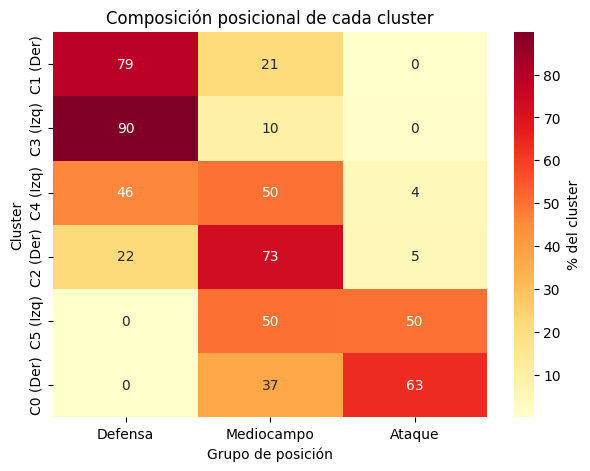

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(tabla_pct, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% del cluster'})
plt.xlabel('Grupo de posición'); plt.ylabel('Cluster')
plt.title('Composición posicional de cada cluster')
plt.show()

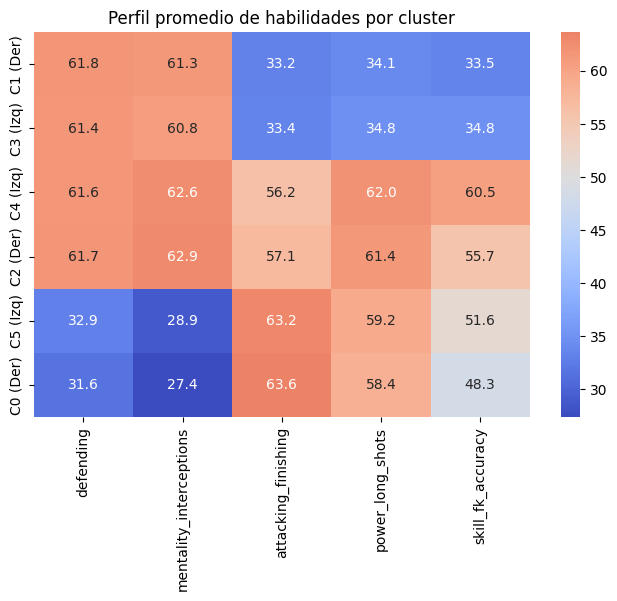

In [ ]:
cols_perfil = ['defending', 'mentality_interceptions', 'attacking_finishing', 'power_long_shots', 'skill_fk_accuracy']
perfil_ordenado = df_perfil.groupby('cluster')[cols_perfil].mean().reindex(orden)
perfil_ordenado.index = tabla_pct.index

plt.figure(figsize=(8, 5))
sns.heatmap(perfil_ordenado, annot=True, fmt='.1f', cmap='coolwarm', center=50)
plt.title('Perfil promedio de habilidades por cluster')
plt.show()

## ----- Punto 5: Análisis cualitativo de los clusters -----

**¿Qué hay en cada cluster?**

El perfil promedio de habilidades (heatmap) y la composición posicional (heatmap
normalizado por fila) muestran una estructura clara y consistente: **3 arquetipos
futbolísticos, cada uno partido en dos por pie preferido** (6 clusters en total).

- **Defensores puros**: Cluster 1 (diestro) y Cluster 3 (zurdo): `defending` y
  `mentality_interceptions` altos (~ 62) y ataque bajo (~ 34). Composición posicional
  muy homogénea: 79 - 90% del cluster son posiciones defensivas (`CB`, `LB`/`RB`). El cluster `1` tambien tiene gran cantidad de `CDM` mientras que el `3` tiene `LWB`.
- **"Completos"**: Cluster 2 ( diestro) y Cluster 4 (zurdo): altos simultáneamente en
  defensa (~ 62) y en ataque (~ 56 - 62), no son un punto intermedio/mediocre entre los
  otros dos arquetipos, sino jugadores con ambas facetas desarrolladas. Composición
  posicional dominada por mediocampo (`CM`, `CDM`), entre 50-73%, con una porción de posiciones
  defensivas (`RB` y `LB`) entre 22-46% y casi nada de ataque puro.
- **Atacantes**: Cluster 0 (diestro) y Cluster 5 (zurdo): defensa baja (~ 28-33), ataque
  alto (~48-64). Composición alta de delanteros (`ST`) con gran porcentaje (37-50%) de mediocampo (`LM/RM`, `CAM`).

**Importante**: El pie preferido es la variable más determinante de todo el
espacio de atributos. Los 6 clusters quedaron partidos de forma perfectamente limpia
por `preferred_foot_enc` (1.0 o 0.0 exacto en cada uno, sin mezcla), y recién *dentro*
de cada mitad aparecen los 3 arquetipos de habilidad. Este resultado se valida además de
forma cruzada: HDBSCAN que encontró exactamente la misma partición binaria en su
configuración `eom` (12066 diestros vs. 4239 zurdos — idéntico a la suma de los
clusters diestros/zurdos de K-Means). Dos métodos independientes coincidiendo en que
esta es la división dominante del espacio de atributos y es una evidencia fuerte de que no
es un artefacto de un solo algoritmo.

Cabe una reflexión crítica: al escalar `preferred_foot_enc` (binaria) junto con las 5
variables continuas en el mismo `StandardScaler`, es esperable que una variable binaria
bien balanceada en la muestra actúe como un eje de separación muy "limpio" para K-Means
(divide el espacio en dos mitades perfectamente equidistantes), lo cual pudo amplificar
su peso relativo frente a atributos continuos con distribuciones más solapadas. No
invalida el resultado ya que el pie es, de hecho, futbolísticamente relevante para decidir
reemplazos, pero vale la pena notar que su dominancia en la partición podría deberse en
parte a esta característica estadística y no únicamente a su importancia futbolística.

**¿Son efectivamente equivalentes los jugadores de un cluster?**

Depende de qué tipo de equivalencia se busque. En términos de **perfil de habilidad**
(los 6 atributos usados para clusterizar), sí, es justamente lo que optimiza K-Means.
Pero mirando el detalle posicional dentro de cada cluster aparece un matiz importante:
dentro del Cluster 1 (defensor, diestro) conviven en volumen significativo `CB` (2164),
`CDM` (483) y `RB` (766), mismo perfil numérico de habilidad, pero un central y un
lateral derecho no son necesariamente equivalentes tácticamente en la formación de un
equipo real, aunque compartan niveles similares de marca e interceptación. La
equivalencia que captura el clustering es de **capacidad**, no de **rol táctico
específico**.

**¿Qué explica la heterogeneidad interna de los clusters?**

El caso más claro es el de los **laterales**, que aparecen repartidos entre dos
clusters distintos en vez de concentrarse en uno solo: `RB` se reparte entre el Cluster
1 (766 casos, perfil defensivo puro) y el Cluster 2 (410 casos, perfil "completo");
mismo patrón con `LB` entre Clusters 3 y 4. Esto tiene sentido futbolístico: no todos
los laterales son iguales, hay laterales de marca pura y laterales con
perfil más ofensivo (aporte en ataque, centros, llegada por el costado). El clustering
está distinguiendo esa diferencia real de estilo de juego dentro de una misma etiqueta
de posición nominal, en vez de agrupar solo por el nombre de la posición, evidencia de
que el modelo captura habilidad real, no una etiqueta categórica.

**¿Qué motiva las diferencias de tamaño entre clusters?**

Los tamaños (4099, 4047, 3920 para los clusters diestros; 1624, 1470, 1145 para los
zurdos) se explican casi enteramente por la proporción real de jugadores diestros vs.
zurdos en el plantel general (~74%/26%, consistente con la distribución de
`preferred_foot` ya relevada en el Punto 1), y no por una escasez marcada de algún
arquetipo de habilidad en particular. Los 3 arquetipos tienen tamaños relativamente
comparables *dentro* de cada mitad de pie (ninguno domina desproporcionadamente sobre
los otros dos del mismo pie).

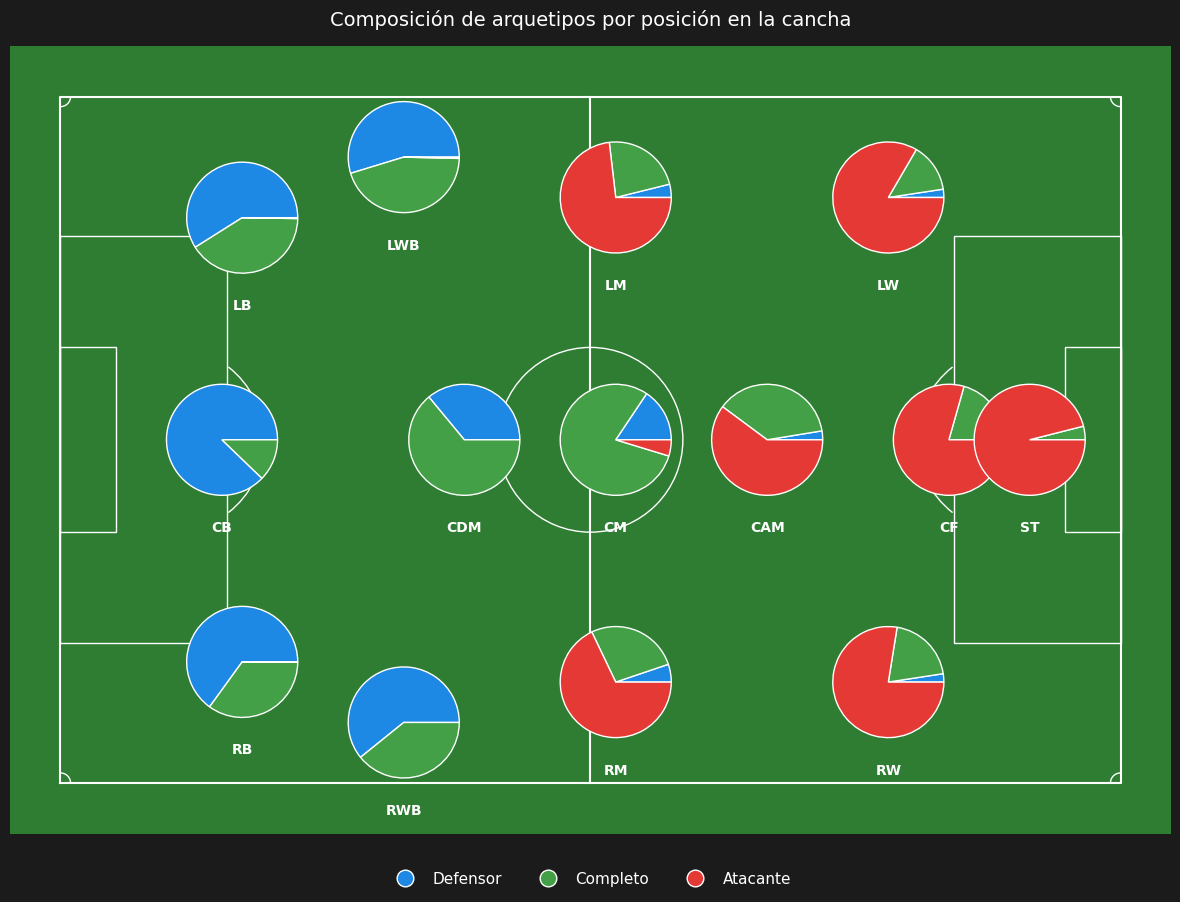

In [ ]:
mapa_arquetipo = {0: 'Atacante', 1: 'Defensor', 2: 'Completo',
                   3: 'Defensor', 4: 'Completo', 5: 'Atacante'}
df_perfil['arquetipo'] = df_perfil['cluster'].map(mapa_arquetipo)

tab_pos_arq = pd.crosstab(df_perfil['posicion_principal'], df_perfil['arquetipo'])
prop_pos_arq = tab_pos_arq.div(tab_pos_arq.sum(axis=1), axis=0)

colores_arquetipo = {'Defensor': '#1e88e5', 'Completo': '#43a047', 'Atacante': '#e53935'}
orden_arquetipos = ['Defensor', 'Completo', 'Atacante']

fig, ax = plt.subplots(figsize=(13, 9))
dibujar_cancha(ax)

radio = 5.5  # más grande que antes, ahora que hay solo 3 porciones como máximo

for pos, (x, y) in posiciones.items():
    if pos not in prop_pos_arq.index:
        continue
    angulo_inicio = 0
    for arq in orden_arquetipos:
        frac = prop_pos_arq.loc[pos, arq] if arq in prop_pos_arq.columns else 0
        if frac <= 0:
            continue
        angulo_fin = angulo_inicio + frac * 360
        wedge = Wedge((x, y), radio, angulo_inicio, angulo_fin,
                      facecolor=colores_arquetipo[arq], edgecolor='white',
                      linewidth=1, zorder=3)
        ax.add_patch(wedge)
        angulo_inicio = angulo_fin
    ax.text(x, y - radio - 2.5, pos, ha='center', va='top', fontsize=10,
            fontweight='bold', color='white', zorder=4)

leyenda_arq = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colores_arquetipo[a],
           markeredgecolor='white', markersize=12, label=a)
    for a in orden_arquetipos
]
leg = ax.legend(handles=leyenda_arq, loc='upper center',
                bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=False, fontsize=11)
for text in leg.get_texts():
    text.set_color('white')

ax.set_title('Composición de arquetipos por posición en la cancha',
              color='white', fontsize=14, pad=15)
fig.patch.set_facecolor('#1b1b1b')
plt.tight_layout()
plt.savefig('mapa_arquetipos_posiciones.png', dpi=200, facecolor=fig.get_facecolor())
plt.show()

Este gráfico muestra que habilidades tiene cada posición en la cancha, demostrando que las posiciones son combinaciones de habilidades diferentes, aunque algunas predominen mas que otras.

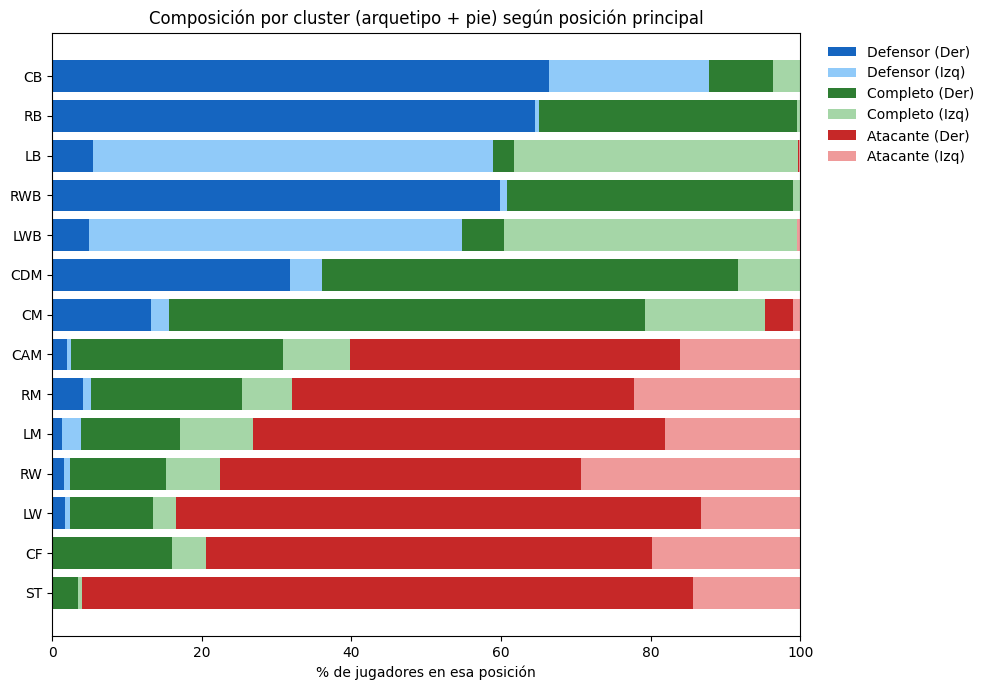

In [ ]:
etiquetas_cluster = {
    1: 'Defensor (Der)', 3: 'Defensor (Izq)',
    2: 'Completo (Der)', 4: 'Completo (Izq)',
    0: 'Atacante (Der)', 5: 'Atacante (Izq)'
}
colores_cluster = {
    1: '#1565c0', 3: '#90caf9',   # azules: Defensor
    2: '#2e7d32', 4: '#a5d6a7',   # verdes: Completo
    0: '#c62828', 5: '#ef9a9a'    # rojos: Atacante
}
orden_clusters = [1, 3, 2, 4, 0, 5]

tab_pos_cluster = pd.crosstab(df_perfil['posicion_principal'], df_perfil['cluster'])
prop_pos_cluster = tab_pos_cluster.div(tab_pos_cluster.sum(axis=1), axis=0)

orden_posiciones = ['CB', 'RB', 'LB', 'RWB', 'LWB', 'CDM', 'CM', 'CAM',
                     'RM', 'LM', 'RW', 'LW', 'CF', 'ST']
prop_pos_cluster_ordenado = prop_pos_cluster.reindex(orden_posiciones)

fig, ax = plt.subplots(figsize=(10, 7))
izquierda = pd.Series(0, index=prop_pos_cluster_ordenado.index)

for c in orden_clusters:
    valores = prop_pos_cluster_ordenado[c] * 100
    ax.barh(prop_pos_cluster_ordenado.index, valores, left=izquierda,
            color=colores_cluster[c], label=etiquetas_cluster[c])
    izquierda += valores

ax.set_xlabel('% de jugadores en esa posición')
ax.set_title('Composición por cluster (arquetipo + pie) según posición principal')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 6 Visualizaciones

 Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print('Total 2 componentes:', pca.explained_variance_ratio_.sum())

[0.49375893 0.27442114]
Total 2 componentes: 0.7681800720014809


In [ ]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


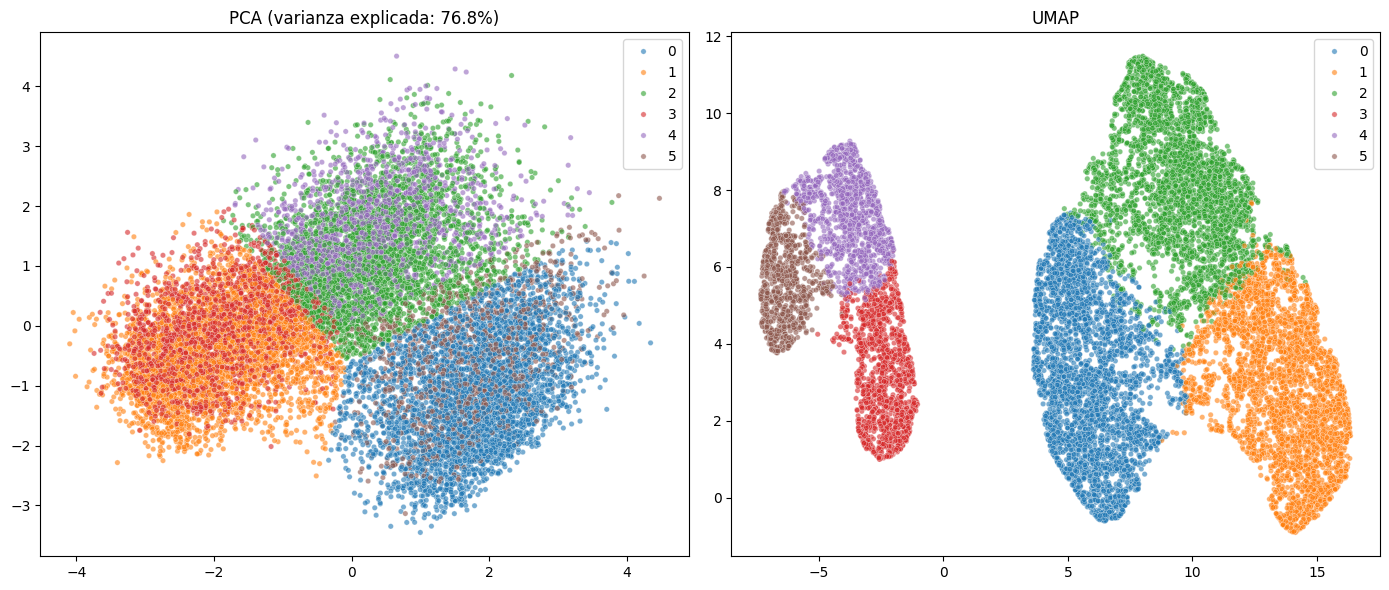

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10', s=15, alpha=0.6, ax=axes[0])
axes[0].set_title(f'PCA (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels, palette='tab10', s=15, alpha=0.6, ax=axes[1])
axes[1].set_title('UMAP')

plt.tight_layout()
plt.show()

Realizamos dos visualizaciones, el clásico PCA y UMAP, donde los datos son transformados en dos dimensiones y se colorean según el cluster al cual se asignaron por el método K-means. Es evidente que la transformación UMAP separa mejor los clusters. Primero vemos dos grupos bien divididos que se corresponden con el pie izquierdo (colores marrón, violeta y rojo) y pie derecho (azul, verde y anaranjado). Luego dentro de cada subgrupo están los clusters por arquetipo de jugador.

Por otro lado, en la visualización de componentes principales, los clusters están mas mezclados. Si bien retiene un 76.8% de la varianza total de los datos originales, la proyección lineal de PCA puede no ser óptima para separar grupos que tienen estructuras no lineales en dimensiones más altas. Esto contrasta con UMAP ya que este método es una técnica de reducción de dimensionalidad **no lineal** y está diseñada para preservar mejor las estructuras locales de los datos.

In [ ]:
km_pca = KMeans(n_clusters=6, n_init=10, random_state=42)
labels_pca = km_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)

km_umap = KMeans(n_clusters=6, n_init=10, random_state=42)
labels_umap = km_umap.fit_predict(X_umap)
sil_umap = silhouette_score(X_umap, labels_umap)

print(f'Silhouette original (6D): 0.361')
print(f'Silhouette sobre PCA (2D): {sil_pca:.3f}')
print(f'Silhouette sobre UMAP (2D): {sil_umap:.3f}')

Silhouette original (6D): 0.361
Silhouette sobre PCA (2D): 0.362
Silhouette sobre UMAP (2D): 0.462


La transformación que mejor separa los clusters se ve reflejada también en el coeficiente de silhouette, siendo mayor para UMAP de 0.462 frente a 0.362 obtenido con PCA y de 0.361 para el dataset original con 6 atributos.

# 7- Comparación con LLM's

Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters, para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.



a) Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

b) Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

c) Documentar textualmente (o via capturas) las tres respuestas obtenidas.

d) Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

  - Coincidencias y diferencias entre los tres modelos.

  - Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

  - Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

  - Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

  - Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

e) Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?

## Prompt

In [ ]:
cols_perfil_completo = cols_perfil + ['preferred_foot_enc']

tabla_para_llms = df_perfil.groupby('cluster')[cols_perfil_completo].mean().round(2)
tabla_para_llms['n_jugadores'] = df_perfil['cluster'].value_counts()
tabla_para_llms

,defending,mentality_interceptions,attacking_finishing,power_long_shots,skill_fk_accuracy,preferred_foot_enc,n_jugadores
cluster,,,,,,,
0,31.64,27.41,63.63,58.45,48.31,1.0,4099
1,61.77,61.26,33.16,34.11,33.48,1.0,4047
2,61.68,62.88,57.11,61.35,55.72,1.0,3920
3,61.40,60.84,33.43,34.76,34.83,0.0,1624
4,61.57,62.60,56.22,62.02,60.51,0.0,1470
5,32.94,28.89,63.19,59.21,51.57,0.0,1145



Tengo un análisis de clustering (K-Means, k=6) sobre jugadores de fútbol de un
videojuego de simulación deportiva (EA Sports FC 24). Cada jugador tiene atributos de
habilidad en escala 0-99 (excepto uno binario). Se usaron estas 6 variables para clusterizar:

Esta es la tabla de centroides (promedio de cada variable por cluster) y el tamaño de
cada cluster:

| cluster | defending | mentality_interceptions | attacking_finishing | power_long_shots | skill_fk_accuracy | preferred_foot_enc | n_jugadores |
|---|---|---|---|---|---|---|---|
| 0 | 31.64 | 27.41 | 63.63 | 58.45 | 48.31 | 1.0 | 4099 |
| 1 | 61.77 | 61.26 | 33.16 | 34.11 | 33.48 | 1.0 | 4047 |
| 2 | 61.68 | 62.88 | 57.11 | 61.35 | 55.72 | 1.0 | 3920 |
| 3 | 61.40 | 60.84 | 33.43 | 34.76 | 34.83 | 0.0 | 1624 |
| 4 | 61.57 | 62.60 | 56.22 | 62.02 | 60.51 | 0.0 | 1470 |
| 5 | 32.94 | 28.89 | 63.19 | 59.21 | 51.57 | 0.0 | 1145 |

Por favor:
1. Interpretá qué representa cada uno de los 6 clusters.
2. Evaluá si los jugadores dentro de un mismo cluster podrían considerarse
   "equivalentes".
3. Sugerí qué podría explicar la heterogeneidad interna de cada cluster, o las
   diferencias de tamaño entre ellos.

## Chat GPT

Sí. La estructura de los centroides permite interpretar bastante bien los 6 grupos. Hay, además, una característica muy importante: **los clusters parecen estar organizados primero por perfil de habilidad y, dentro de varios de esos perfiles, por pie preferido**.

### 1. Interpretación de los clusters

Primero conviene separar las variables en dos grandes bloques:

* **Defensa:** `defending` + `mentality_interceptions`
* **Ataque:** `attacking_finishing` + `power_long_shots` + `skill_fk_accuracy`
* **Pie preferido:** `preferred_foot_enc` (0/1)

Con eso, los clusters quedan bastante claros:

| Cluster | Interpretación                                                  | Características principales                                                                        |
| ------- | --------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| **0**   | **Atacantes de perfil derecho**                                 | Defensa baja (~ 30), finalización alta (~ 64), tiros lejanos altos (~ 58), FK moderada (~ 48), pie = 1 |
| **1**   | **Defensores de perfil derecho**                                | Defensa alta (~ 62), intercepciones altas (~ 61), pero ataque bajo (~ 33–34), FK baja, pie = 1        |
| **2**   | **Jugadores completos/ofensivo-defensivos de perfil derecho**   | Defensa alta (~ 62), ataque también alto (~ 56–61), FK relativamente alta (~ 56), pie = 1             |
| **3**   | **Defensores de perfil izquierdo**                              | Prácticamente igual al cluster 1 en habilidades, pero pie = 0                                      |
| **4**   | **Jugadores completos/ofensivo-defensivos de perfil izquierdo** | Muy similares al cluster 2, pero pie = 0                                                           |
| **5**   | **Atacantes de perfil izquierdo**                               | Muy similares al cluster 0, pero pie = 0                                                           |

Esto muestra algo particularmente interesante:

![Image](https://images.openai.com/static-rsc-4/wtBCOK7NTaPCL2IQu7mX3e1qflu3sNS3xkXUJ6P4hl1S-Hlk1tC6T6-QSZLIVI7xqpTXvkvR7NYKli4L3aYpAVIetNeAE2oXxAHA66ahNJw3m2sT93YO6f8qXXVSQs5FNoZfCL-SRaA1uypD3DFwDcZGCJ4nDP_X-ow0ds_F3keEyrCwyuv_lovn7RsN4xHn?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/yiuoJEFgId0J0GY6JOU-R-UInJGJgx_gJoTbLL6yxDHVqv38ujyNqeqofDlk4ViZ22BFU5PDI32qClaohMpKP7PiapETVhgsvFgufLvPaWQrzfxRfQbq4WqqyBJYeCNE9hLRpx87s_FT62mwfZJm_EBGby4wFzCP5silFKyRYsyNidWmiLfn2E_wINW6t3y2?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/3rOizJK1aupJaz2ktAfdl4m_ZIsxsud4H2fIqRL8zhRtgLN6FyFklkBhazi3e54CrePJcUehL7_IrC0ksCeH57gIBcFBhXqXASQifdQRHb54sWmVaproINh-pL9CyHXg_kz50m_GbLwB-I6K2bNC794Qq15SKTlKtk7z_jDT-pZcvKrJz0kGMZWYWOHQv7rS?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/HlRzDjaB2_jKOUUsZAQ-4QZTZEyuQLNcXBq07oGdjxvR9wsnCfzVdQIeLhBgsY7v6X4Z29HLVFllHuVFmkzSDl6xLYiUQnsZJX08-O2tI2tAzsp8y-8FbVY1U4MRwbcFX5pSuSeSXpPpy6MxkzEdIeRLImdHBLclY5k4puNPRLs01B3aOCNSQm_z313Q6WtM?purpose=fullsize)

Hay **tres perfiles principales de habilidad**:

1. **Perfil defensivo:** defensa alta + ataque bajo → clusters **1 y 3**.
2. **Perfil mixto/completo:** defensa alta + ataque alto → clusters **2 y 4**.
3. **Perfil ofensivo:** defensa baja + ataque alto → clusters **0 y 5**.

Y cada uno aparece dividido aproximadamente por `preferred_foot_enc`.

---

### 2. ¿Los jugadores de un mismo cluster son "equivalentes"?

Acá haría una distinción importante:

> **No sería correcto interpretar que los jugadores de un cluster son equivalentes. Son jugadores similares respecto de las seis variables utilizadas para construir el clustering.**

Esto es fundamental porque K-Means está agrupando en un espacio de **seis dimensiones**, no en el concepto global de "tipo de jugador".

Por ejemplo, el cluster 0 tiene:

* `defending` ≈ 32
* `mentality_interceptions` ≈ 27
* `attacking_finishing` ≈ 64
* `power_long_shots` ≈ 58
* `skill_fk_accuracy` ≈ 48
* pie = 1

Eso significa que el **jugador promedio** del cluster tiene ese perfil.

Pero dos jugadores dentro del cluster pueden ser bastante diferentes.

Por ejemplo:

* Jugador A: defensa 20, finishing 75, long shots 70.
* Jugador B: defensa 40, finishing 55, long shots 45.

Ambos podrían caer en el mismo cluster, aunque desde el punto de vista futbolístico no sean particularmente equivalentes.

### Una cuestión todavía más importante

Los centroides **no permiten saber cuánto varían los jugadores alrededor del centroide**.

Por ejemplo, para el cluster 0 sabemos que:

[
\overline{finishing}=63.63
]

pero no sabemos si:

[
finishing \in [60,67]
]

para casi todos los jugadores, o si existe una dispersión mucho mayor:

[
finishing \in [30,90].
]

Ambos casos producirían el mismo centroide.

Por eso, **la tabla de centroides sirve para interpretar los clusters, pero no para evaluar su homogeneidad interna**.

Para afirmar que los jugadores de un cluster son realmente similares habría que analizar, como mínimo:

* desviación estándar por variable;
* rango o percentiles;
* distancia de cada jugador al centroide;
* distribución de esas distancias;
* eventualmente silhouette score.

---

### 3. ¿Qué puede explicar la heterogeneidad interna?

Hay varias fuentes posibles.

### A. K-Means obliga a simplificar perfiles continuos

K-Means divide un espacio continuo en **seis regiones**.

Supongamos que tenemos jugadores con una transición gradual:

```text
Defensa
  ↑
90 |       D
80 |      D D
70 |    D D D
60 |  D D D
50 |     M M M
40 |       M M
30 |           A A
20 |             A A
   +--------------------→ Ataque
```

No necesariamente existen "seis tipos naturales" de jugadores.

Puede existir un **continuo de perfiles**, y K-Means simplemente corta ese continuo en seis regiones.

Por eso, cierta heterogeneidad dentro de cada cluster es completamente esperable.

---

### B. Las seis variables no contienen toda la información futbolística

Este es probablemente uno de los puntos más importantes.

Dos jugadores pueden tener valores muy similares en estas seis variables pero ser completamente diferentes en otros atributos.

Por ejemplo, no estamos considerando:

* velocidad;
* aceleración;
* pase;
* regate;
* físico;
* stamina;
* altura;
* fuerza;
* posicionamiento;
* visión;
* etc.

Entonces, podríamos tener:

> Jugador A y jugador B → muy similares según las 6 variables.

pero:

> Jugador A y jugador B → muy diferentes considerando el conjunto completo de atributos del juego.

Por lo tanto, la equivalencia es **local al espacio de variables seleccionado**.

---

### C. Variables omitidas que podrían generar subgrupos

El cluster 2 es un buen ejemplo.

Su centroide es:

* defensa ≈ 62
* intercepciones ≈ 63
* finishing ≈ 57
* long shots ≈ 61
* FK ≈ 56

Es decir, parece representar un jugador bastante completo.

Pero ahí podrían convivir:

* mediocampistas;
* defensores con buena capacidad ofensiva;
* laterales;
* mediapuntas con buena defensa;
* incluso jugadores de otras posiciones.

Todos pueden terminar juntos porque las seis variables utilizadas los consideran similares.

Esto no significa que sean "el mismo tipo de jugador" desde una perspectiva futbolística.

---

### 4. ¿Qué explica que haya clusters de tamaños tan diferentes?

Acá hay un patrón muy interesante.

Los tamaños son:

| Cluster | Jugadores |
| ------- | --------: |
| 0       |      4099 |
| 1       |      4047 |
| 2       |      3920 |
| 3       |      1624 |
| 4       |      1470 |
| 5       |      1145 |

Los tres clusters con `preferred_foot_enc = 1` son mucho más grandes que sus equivalentes con `preferred_foot_enc = 0`.

De hecho:

* pie = 1 → 4099 + 4047 + 3920 = **12.066 jugadores**
* pie = 0 → 1624 + 1470 + 1145 = **4.239 jugadores**

Eso es aproximadamente:

[
\frac{12066}{4239}\approx2.85
]

Es decir, hay **casi 2,85 veces más jugadores del grupo codificado como 1 que del grupo codificado como 0**.

Esto sugiere fuertemente que **la diferencia de tamaños no está causada principalmente por K-Means**, sino por la distribución original de `preferred_foot_enc`.

Si `1` representa, por ejemplo, pie derecho y `0` pie izquierdo, entonces simplemente habría muchos más jugadores diestros que zurdos en el dataset.

---

### Hay además una simetría muy llamativa

Podemos comparar los clusters:

### 1 ↔ 3

| Variable      | Cluster 1 | Cluster 3 |
| ------------- | --------: | --------: |
| defending     |     61.77 |     61.40 |
| interceptions |     61.26 |     60.84 |
| finishing     |     33.16 |     33.43 |
| long shots    |     34.11 |     34.76 |
| FK            |     33.48 |     34.83 |
| pie           |     **1** |     **0** |

Son prácticamente iguales.

### 2 ↔ 4

También son extremadamente similares:

| Variable      | Cluster 2 | Cluster 4 |
| ------------- | --------: | --------: |
| defending     |     61.68 |     61.57 |
| interceptions |     62.88 |     62.60 |
| finishing     |     57.11 |     56.22 |
| long shots    |     61.35 |     62.02 |
| FK            |     55.72 |     60.51 |
| pie           |     **1** |     **0** |

### 0 ↔ 5

Y nuevamente:

| Variable      | Cluster 0 | Cluster 5 |
| ------------- | --------: | --------: |
| defending     |     31.64 |     32.94 |
| interceptions |     27.41 |     28.89 |
| finishing     |     63.63 |     63.19 |
| long shots    |     58.45 |     59.21 |
| FK            |     48.31 |     51.57 |
| pie           |     **1** |     **0** |

Esto es muy revelador.

**K-Means parece haber encontrado tres perfiles de habilidad y haberlos duplicado según el pie preferido.**

Por eso yo describiría el resultado como:

> **3 perfiles principales de habilidad × 2 categorías de pie preferido = 6 clusters.**

---

### 5. ¿Qué pasa con la heterogeneidad de cada cluster?

Podés pensarla en tres niveles.

### Cluster 0/5 — ofensivos

Probablemente tengan heterogeneidad porque dentro de este grupo pueden coexistir distintos tipos de atacantes:

* delanteros;
* extremos;
* mediapuntas;
* jugadores ofensivos con buen disparo.

Todos comparten **baja defensa y alta capacidad de finalización/disparo**, pero pueden diferir mucho en otros atributos.

### Cluster 1/3 — defensivos

Pueden incluir:

* centrales;
* laterales;
* mediocentros defensivos;
* otros jugadores con buenas capacidades defensivas.

La diferencia entre ellos podría estar en velocidad, pase, físico, etc., variables que no se usaron.

### Cluster 2/4 — completos

Probablemente sean los más interesantes desde el punto de vista de la heterogeneidad.

El centroide indica:

> "buena defensa + buen ataque".

Pero eso puede describir muchísimas situaciones futbolísticas diferentes.

Por ejemplo:

* un mediocampista box-to-box;
* un lateral ofensivo;
* un volante;
* un defensor con excelente capacidad ofensiva.

Por lo tanto, **el mismo centroide puede esconder una diversidad posicional considerable**.

---

### 6. Una interpretación que yo evitaría

No diría:

> "El cluster 0 representa a los delanteros."

Porque el clustering **no utilizó la posición del jugador**.

Diría:

> "El cluster 0 agrupa jugadores con un perfil caracterizado por bajos valores de atributos defensivos y altos valores de finalización y disparo, dentro del grupo de jugadores cuyo pie preferido corresponde a la categoría codificada como 1."

Eso es metodológicamente mucho más sólido.

Y lo mismo para los demás.

---

### Conclusión

El resultado parece tener una estructura bastante clara:

[
\boxed{\text{Perfil de habilidad} \times \text{pie preferido}}
]

con:

[
\begin{aligned}
\text{Perfil A} &= \text{ofensivo}\
\text{Perfil B} &= \text{defensivo}\
\text{Perfil C} &= \text{completo}
\end{aligned}
]

y cada uno dividido en:

[
\text{preferred_foot}=0/1.
]

Por eso los centroides **0 y 5**, **1 y 3**, y **2 y 4** son tan parecidos respectivamente.

La principal conclusión metodológica sería:

> **Los clusters no deberían interpretarse como grupos de jugadores equivalentes en términos futbolísticos generales, sino como grupos de jugadores similares en el espacio definido por las seis variables seleccionadas. La heterogeneidad interna puede provenir tanto de la dispersión natural de los atributos como de la información futbolística omitida del clustering.**

Y hay una comprobación que sería especialmente valiosa: **calcular la dispersión interna de cada cluster**. Con las desviaciones estándar de las seis variables y, sobre todo, la distribución de la **distancia de cada jugador a su centroide**, podríamos determinar si estos seis grupos son realmente compactos o si algunos centroides están representando poblaciones muy heterogéneas.


## Gemini

Es un excelente ejercicio de análisis de datos aplicado al deporte. Lo primero que salta a la vista al observar los centroides es que el algoritmo **no encontró 6 perfiles tácticos distintos, sino 3 perfiles que se bifurcaron por la pierna hábil**.

Como la variable `preferred_foot_enc` tiene promedios exactos de `1.0` y `0.0`, el K-Means logró una partición pura en esta característica. Dado que los clusters 0, 1 y 2 concentran aproximadamente al 75% de los jugadores, podemos deducir con seguridad que **`1.0` representa a los diestros y `0.0` a los zurdos** (lo cual coincide con la demografía real del fútbol).

Aquí tenés el desglose de lo que revelan tus datos:

### 1. Interpretación de los Clusters

Podemos emparejar los clusters según sus estadísticas de juego:

* **Clusters 0 (Diestros) y 5 (Zurdos) - Los Atacantes Puros:**
Tienen las estadísticas defensivas más bajas del dataset (~30), pero destacan rotundamente en definición (`attacking_finishing` > 63) y tiros delarga distancia (`power_long_shots` > 58). Son los típicos delanteros centro (DC), extremos ofensivos o mediapuntas cuya principal tarea es hacer goles, desentendiéndose de la recuperación de balón.
* **Clusters 1 (Diestros) y 3 (Zurdos) - Los Defensores Puros:**
Es el perfil inverso al anterior. Altos valores en defensa e intercepciones (> 60), pero nula capacidad ofensiva y de tiro libre (~33). Aquí caen los defensores centrales (DFC), laterales puramente defensivos, y probablemente algunos mediocampistas de contención (MCD) muy rústicos. *(Nota: Es muy probable que los arqueros también hayan caído en estos clusters debido a sus bajas estadísticas de tiro).*
* **Clusters 2 (Diestros) y 4 (Zurdos) - Los Todoterreno (Box-to-Box / Mixtos):**
Tienen promedios altos en *absolutamente todo*. Defienden bien (> 61), atacan bien (> 56) y son los mejores pateadores de tiros libres del juego (> 55). Estos son los mediocampistas completos (MC, MCO, laterales ofensivos), jugadores que participan en ambas fases del juego.

---

### 2. ¿Son "equivalentes" los jugadores dentro del mismo cluster?

**No, de ninguna manera.** En clustering, pertenecer a un mismo grupo indica "similitud de perfil", no "equivalencia de calidad o función". Dos jugadores en el Cluster 0 no son intercambiables por las siguientes razones:

1. **Diferencia de jerarquía (Overall Rating):** Kylian Mbappé (delantero top, stats altísimas) y un delantero de bronce de la tercera división inglesa de 60 de media caerán en el Cluster 0. Sus "formas" estadísticas son similares (más ataque que defensa), pero su calidad absoluta es abismalmente distinta.
2. **Compensación de distancias (Euclidiana):** En el Cluster 2, un jugador podría tener 80 en defensa y 40 en ataque, y otro tener 40 en defensa y 80 en ataque. En promedio se anulan y quedan cerca del centroide, pero en el campo de juego uno es un defensor adelantado y el otro un enganche retrasado.
3. **Faltan variables críticas:** Al no incluir ritmo (velocidad), pase, regate o físico, estás agrupando en el mismo lugar a un "tanque" de área alto y lento, junto a un extremo bajito y veloz (ambos en los clusters 0 o 5).

---

### 3. Explicación de las diferencias de tamaño y la heterogeneidad

**Diferencias de tamaño entre clusters:**

* **Biología y Demografía:** La diferencia enorme entre los bloques (12.066 diestros vs 4.239 zurdos) refleja simplemente que solo ~25% de la población mundial (y de los futbolistas) es zurda.
* **Táctica del fútbol:** Si sumás los clusters por rol, tenés unos 5.200 atacantes, 5.600 defensores y 5.300 mediocampistas. La distribución es notablemente equitativa porque un equipo de fútbol real (y por ende el videojuego) requiere un balance parecido de posiciones (ej. un esquema 4-3-3 o 4-4-2 usa proporciones similares de estos roles).

**Origen de la heterogeneidad interna:**
La heterogeneidad dentro de los clusters existe porque **K-Means fuerza a que todos los puntos pertenezcan a un grupo**, incluso los valores atípicos (outliers).
Por ejemplo, los defensores con excelente pegada de tiro libre (como Ronald Koeman o Roberto Carlos en versiones de Íconos) no encajan perfectamente ni en el cluster de defensores puros ni en el de mediocampistas, por lo que el algoritmo los asigna al grupo "menos lejano", deformando ligeramente el cluster por dentro.

## Claude



### 1. Interpretación de los clusters

Si mirás los centroides con atención, notás algo importante: **no hay 6 perfiles de habilidad distintos, hay 3**, y cada uno aparece duplicado por pie hábil:

| Perfil de habilidad | Clusters | defending | interceptions | finishing | long_shots | fk_accuracy | Interpretación |
|---|---|---|---|---|---|---|---|
| **Atacante puro** | 0 (diestro) y 5 (zurdo) | ~32 | ~28 | ~63 | ~59 | ~50 | Delanteros/extremos: buena definición y disparo lejano, defensa casi nula |
| **Defensor puro** | 1 (diestro) y 3 (zurdo) | ~61 | ~61 | ~33 | ~34 | ~34 | Defensores centrales/laterales: fuertes en marca e intercepciones, débiles en ataque |
| **Todo terreno / completo** | 2 (diestro) y 4 (zurdo) | ~62 | ~63 | ~57 | ~62 | ~55-60 | Mediocampistas box-to-box o "complete players": altos en las 5 variables, sin debilidad marcada |

Dentro de cada perfil, la diferencia entre el cluster "diestro" y el "zurdo" es mínima en las variables de habilidad (diferencias de 1-2 puntos) — el eje que realmente los separa es `preferred_foot_enc`.

### 2. ¿Son los jugadores de un mismo cluster "equivalentes"?

No, y por varias razones:

- **El centroide es un promedio, no describe la dispersión.** No tenés el desvío estándar dentro de cada cluster, así que no podés saber si un cluster es compacto o si mezcla, por ejemplo, un mediocampista defensivo de élite con uno mediocre que solo cae ahí por cercanía al centroide.
- **Solo usaste 6 variables de un jugador que tiene decenas de atributos.** Dos jugadores pueden tener el mismo `defending`, `interceptions`, `finishing`, etc., y diferir muchísimo en pace, passing, physicality, dribbling, overall rating, posición táctica exacta (lateral vs. central, `CDM` vs `CM`), edad, liga, etc. "Equivalente" en estas 6 dimensiones no es equivalente como jugador.
- **K-Means asume clusters esféricos y de tamaño/varianza similar**, lo cual rara vez se cumple con datos reales de habilidades (hay mucha correlación entre `finishing`/`long_shots`/`fk_accuracy` y entre `defending`/`interceptions`, así que el espacio real de variación es más bajo-dimensional de lo que sugieren 6 variables).
- Cada jugador se asigna al centroide más cercano aunque esté lejos de él (no hay umbral de pertenencia), por lo que siempre hay "miembros marginales" mal representados por el promedio.

Para responder esto con más rigor te convendría mirar el **silhouette score por cluster** o el desvío estándar de cada variable dentro de cada cluster.

### 3. Heterogeneidad interna y diferencias de tamaño

**Heterogeneidad interna**, probablemente explicada por:
- Variables no incluidas en el clustering (pace, passing, physical, dribbling, goalkeeping) que sí varían mucho entre jugadores con el mismo perfil defensivo/ofensivo — por ejemplo, dentro del cluster "defensor puro" seguramente conviven laterales rápidos con centrales lentos y fuertes.
- Diferencias de nivel general (overall rating): un defensor de 65 y uno de 85 pueden caer en el mismo cluster si el *patrón relativo* entre sus 6 atributos es similar, aunque su calidad absoluta sea muy distinta.
- Posición táctica dentro de un mismo rol amplio (ej. CB vs LB vs RB todos "defienden e interceptan" pero cumplen funciones distintas).

**Diferencias de tamaño entre clusters**, dos factores probables:
- **Pie hábil**: en la vida real (y en la base de datos de FC24) los jugadores diestros son mayoría (~75-80%), lo que explica por qué los clusters "diestros" (0, 1, 2) son sistemáticamente más grandes que sus pares "zurdos" (5, 3, 4) — la proporción se mantiene bastante estable (4099/1145 ≈ 3140/1470 ≈ 3.5, 4047/1624 ≈ 2.5).
- **Distribución de roles en el juego**: hay más jugadores catalogados como defensores "puros" (clusters 1+3 ≈ 5671) y atacantes "puros" (0+5 ≈ 5244) que como "completos" (2+4 ≈ 5390) — son similares en total, pero el reparto diestro/zurdo dentro de cada perfil varía, sugiriendo que la proporción de pie hábil no es idéntica en todas las posiciones (por ejemplo, suele haber más zurdos "reclutados" específicamente para el lateral izquierdo o el ala izquierda).

**Punto metodológico importante que vale la pena que revises:** el hecho de que k=6 haya terminado separando exactamente por pie hábil dentro de cada uno de los 3 perfiles de habilidad sugiere que **la estructura "natural" de tus datos es de 3 clusters, no 6**, y que K-Means usó el pie hábil como el único eje de variación restante para "llenar" los clusters adicionales que le pediste. Esto pasa típicamente cuando:
- Estandarizaste las variables (z-score) antes de clusterizar, lo cual le da a la variable binaria un peso comparable al de las continuas en la distancia euclídea, aun sin ser la fuente principal de variación en el dominio del fútbol.
- Las 5 variables de habilidad están muy correlacionadas entre sí (defending - interceptions, finishing - long_shots -fk_accuracy), reduciendo la dimensionalidad efectiva a ~2 ejes reales, dejando "hueco" para que el pie hábil arme la partición restante.

Te recomendaría correr el método del codo o silhouette con k=3, 4, 5, 6 para comparar, y probablemente excluir `preferred_foot_enc` del clustering (tratarlo como variable descriptiva post-hoc) si tu objetivo es agrupar por *estilo de juego* y no por *lateralidad*.

## Respuesta

### (d) Análisis comparativo

**Coincidencias entre los tres modelos.**

- Los tres, de forma independiente, identificaron la misma estructura de fondo:
  **3 perfiles de habilidad (defensivo / ofensivo / completo) duplicados por
  `preferred_foot_enc`**, la misma lectura a la que había llegado el grupo en el
  Punto 5 con el heatmap y las proyecciones PCA/UMAP.
- Los tres rechazaron explícitamente la idea de que los jugadores de un mismo cluster
  sean "equivalentes", señalando que el centroide es un promedio y no informa sobre
  dispersión interna — coincide con la reflexión del grupo sobre equivalencia de
  *capacidad* vs. equivalencia de *rol táctico*.
- Los tres atribuyeron correctamente la heterogeneidad interna a variables no incluidas
  en el clustering (pace, passing, físico, etc.) y a la naturaleza de K-Means (asigna
  todo punto a algún cluster, incluso outliers marginales).
- Los tres inferiron sin ayuda el significado futbolístico de columnas como
  `mentality_interceptions` o `skill_fk_accuracy` (bloques defensa/ataque, cálculo de la
  proporción diestro/zurdo ≈2.85-3.5x) — incluida la corrida sin descripciones de
  variables, donde ChatGPT mantuvo la misma calidad de interpretación. Es evidencia de
  conocimiento de dominio futbolístico genuino incorporado en los tres modelos, no de
  estar simplemente repitiendo contexto que se les dio en el prompt.

**Diferencias relevantes entre los tres.**

- **Claude** fue el único en plantear una **crítica metodológica de fondo**: que la
  estructura "natural" de los datos podría ser de 3 clusters (no 6), y que el pie
  terminó de "rellenar" las 3 particiones adicionales por haberse escalado junto con
  las variables continuas — coincide punto por punto con la reflexión crítica que el
  grupo ya había anotado en el Punto 5 sobre si el pie domina de forma artificial.
  Ningún otro modelo llegó a este nivel de introspección sobre el propio pipeline de
  clustering.
- **ChatGPT** fue el más cauteloso/metodológico en su fraseo: explícitamente evitó
  afirmaciones del tipo "el cluster 0 representa a los delanteros" (razonando que la
  posición no fue una variable de clustering), y propuso análisis de seguimiento
  concretos (desvío estándar, distancia al centroide, silhouette por cluster).
- **Gemini** tuvo el tono más asertivo de los tres ("no, de ninguna manera", "podemos
  deducir con seguridad") y usó nombres de jugadores reales (Mbappé, Ronald Koeman,
  Roberto Carlos) como ilustración — ejemplos no verificables contra la tabla de
  centroides real del trabajo.

**Casos de alucinación / conclusiones no sustentadas por los números.**

- **Gemini** afirmó que *"es muy probable que los arqueros también hayan caído en estos
  clusters"* (Defensores) por sus bajas estadísticas de tiro. Es **factualmente
  incorrecto en este análisis puntual**: los arqueros fueron excluidos por completo del
  clustering desde el Punto 1 (`df_fc24_campo`), algo que el modelo no podía saber sin
  que se lo dijéramos — nunca se mencionó la exclusión de arqueros en el prompt.
- **Claude** citó una cifra que **no existe** en la tabla proporcionada — *"4099/1145 ≈
  3140/1470 ≈ 2.5"* — donde "3140" no corresponde a ningún cluster (el cluster 2 tiene
  3920 jugadores). Además, presentó las tres proporciones como *"estables ≈2.5"* cuando
  en realidad varían de 2.49 a 3.58 (una diferencia del 44% entre el mayor y el menor) —
  una generalización presentada con seguridad que los propios números no sostienen.

**Casos donde el conocimiento de dominio/proceso del grupo detectó algo que ningún
modelo pudo:**

- La exclusión de arqueros (contradice directamente la especulación de Gemini).
- La composición posicional interna de cada cluster (ej. los laterales `RB`/`LB`
  divididos entre el cluster "defensor puro" y el "completo", visto en el mapa de
  cancha y el gráfico de barras apiladas): ningún modelo pudo mencionar esto porque
  **la posición del jugador nunca fue parte del input** — es información que el grupo
  tiene disponible por trabajar con el dataset completo (`df_perfil`, jugador por
  jugador), mientras que los modelos solo vieron un resumen agregado de 6 filas.
- La decisión concreta de escalar `preferred_foot_enc` junto con las variables
  continuas (que Claude adivinó como hipótesis plausible, pero no podía confirmar) —
  el grupo sabe que efectivamente así se hizo, y puede evaluar el trade-off con
  certeza, no como conjetura.

**Información contextual que un experto humano valora pero los modelos no pueden
inferir solo de los números:** la fecha exacta ("snapshot") de la base afecta lesiones o
rachas de forma que ningún centroide captura; el nivel competitivo desigual entre ligas
puede igualar estadísticas de forma engañosa entre jugadores de calidad muy distinta
(mencionado de forma genérica por los tres modelos como "overall rating" pero sin poder
anclarlo a las ligas reales del dataset, que sí están disponibles en `df_id`).

**Tono de certeza.** Gemini fue notablemente el más asertivo/narrativo de los tres,
llegando a afirmar cosas no verificables con nombres propios reales. ChatGPT fue el más
matizado y metodológicamente cauto en general. Claude combinó ambos extremos: gran
cautela metodológica en la crítica de fondo, pero una afirmación numérica incorrecta
presentada sin matiz alguno — mostrando que incluso el modelo más cuidadoso en un eje
puede deslizar una alucinación con total confianza en otro.

### (e) Conclusión

Los tres modelos aportaron valor real en tareas de **generación rápida de hipótesis** (
los tres llegaron solos a la estructura 3×2, ahorrando tiempo de verificación) y de
**redacción/organización** de una interpretación coherente a partir de una tabla cruda.
También resultaron sorprendentemente sólidos infiriendo significado futbolístico de
nombres de variables sin contexto explícito, lo cual habla de conocimiento de dominio
genuino y no solo de repetir lo que se les da servido.

Sin embargo, resultan **insuficientes o directamente engañosos sin supervisión experta**
en dos frentes concretos: (1) cuando especulan sobre decisiones metodológicas del propio
pipeline que no tienen forma de verificar (la exclusión de arqueros de Gemini, errónea
para este trabajo específico), y (2) cuando generan cifras o generalizaciones numéricas
que no están sustentadas por los datos que se les dieron (el "3140" y la falsa
"estabilidad" de Claude) — en ambos casos, la respuesta *suena* igual de convincente que
el resto del texto, lo cual es precisamente el riesgo: sin conocer ya la respuesta
correcta, sería difícil distinguir a simple vista la parte alucinada de la parte sólida.

En la práctica profesional de un/a científico/a de datos, el rol razonable para estas
herramientas en el análisis de resultados no supervisados sería el de un **primer
lector rápido y generador de hipótesis a validar**, nunca el de fuente final de verdad:
útil para acelerar una primera pasada de interpretación o para redactar un borrador, pero
cada cifra derivada, cada supuesto sobre el pipeline, y cada ejemplo concreto que
mencionen debe contrastarse contra los datos reales antes de incorporarlo a un informe —
exactamente el proceso que se siguió acá, donde el conocimiento del propio trabajo
(qué se excluyó, qué variables no vieron los modelos, qué decisiones de escalado se
tomaron) fue lo que permitió separar los aciertos genuinos de las conjeturas erróneas.

### ----- Función de reemplazo puntual: `sugerir_reemplazos` -----

Además del análisis de clusters en general, nos pareció útil armar una herramienta
concreta que responda la pregunta que motivó todo el trabajo desde el enunciado: si se
lesiona un jugador puntual del plantel, ¿por quién lo cambio?

El cluster de K-Means ya nos da un primer filtro razonable (todos los jugadores de un
mismo cluster comparten perfil de habilidad), pero dentro de un cluster de más de mil
jugadores hace falta un criterio para elegir entre ellos. Para eso armamos una función
que, dado el nombre de un jugador, busca dentro de su mismo cluster a los candidatos con
edad y overall más parecidos, dando prioridad además a quienes juegan en el mismo club.

La función hace lo siguiente:

1. Busca el nombre en `short_name`. Si encuentra más de una coincidencia, no adivina:
   muestra las opciones (con edad, club y posición) para que se especifique mejor el
   nombre y se vuelva a llamar la función.
2. Una vez identificado el jugador, calcula qué tan lejos está cada compañero de
   cluster en edad y en overall, usando el mismo desvío estándar de esas dos variables
   pero calculado solo dentro de ese cluster (no de toda la base). Esto es lo mismo que
   hace `StandardScaler` en el clustering original, aplicado ahora a una escala más
   chica y puntual.
3. Marca si cada candidato juega en el mismo club que el jugador buscado.
4. Ordena primero por esa marca de "mismo club" y después por la cercanía en edad y
   overall, y devuelve los primeros `n` candidatos (por defecto, 3).

In [ ]:
def sugerir_reemplazos(nombre, df, n=3):
    coincidencias = df[df['short_name'].str.contains(nombre, case=False, na=False)]

    if coincidencias.shape[0] == 0:
        print(f"No se encontró ningún jugador que coincida con '{nombre}'.")
        return None

    if coincidencias.shape[0] > 1:
        print(f"Se encontró más de un jugador que coincide con '{nombre}'. Sé más específico:")
        print(coincidencias[['short_name', 'age', 'club_name', 'player_positions']])
        return None

    jugador = coincidencias.iloc[0]
    cluster_jugador = jugador['cluster']

    candidatos = df[
        (df['cluster'] == cluster_jugador) &
        (df['short_name'] != jugador['short_name'])
    ].copy()

    std_edad = df[df['cluster'] == cluster_jugador]['age'].std()
    std_overall = df[df['cluster'] == cluster_jugador]['overall'].std()

    candidatos['dist_edad'] = ((candidatos['age'] - jugador['age']) / std_edad) ** 2
    candidatos['dist_overall'] = ((candidatos['overall'] - jugador['overall']) / std_overall) ** 2
    candidatos['distancia'] = np.sqrt(candidatos['dist_edad'] + candidatos['dist_overall'])

    candidatos['mismo_club'] = candidatos['club_name'] == jugador['club_name']

    candidatos = candidatos.sort_values(['mismo_club', 'distancia'], ascending=[False, True])

    print(f"Jugador buscado: {jugador['short_name']} (edad {jugador['age']}, overall {jugador['overall']}, posición {jugador['player_positions']}, club {jugador['club_name']})")

    return candidatos[['short_name', 'age', 'overall', 'player_positions', 'club_name']].head(n)

In [ ]:
sugerir_reemplazos('Füllkrug', df_perfil, n=5)

Jugador buscado: N. Füllkrug (edad 30, overall 80, posición ST, club Borussia Dortmund)


,short_name,age,overall,player_positions,club_name
184,S. Haller,29,83,ST,Borussia Dortmund
227,D. Malen,24,82,"RM, ST",Borussia Dortmund
657,G. Reyna,20,78,"RM, CAM, LM",Borussia Dortmund
3556,J. Bynoe-Gittens,18,71,LM,Borussia Dortmund
8329,J. Duranville,17,66,"LM, ST, RM",Borussia Dortmund


In [ ]:
sugerir_reemplazos('Silva', df_perfil, n=3)

Se encontró más de un jugador que coincide con 'Silva'. Sé más específico:
           short_name  age                club_name player_positions
24     Bernardo Silva   28          Manchester City           CM, RW
117      Thiago Silva   38                  Chelsea               CB
416       André Silva   27            Real Sociedad               ST
652     António Silva   19                  Benfica               CB
1705         D. Silva   36              Millonarios      CAM, LM, CM
1719         A. Silva   33                  Olimpia           RM, CM
2146      Tiago Silva   30               Vitória SC          CM, CAM
2319      Fábio Silva   20  Wolverhampton Wanderers               ST
2391       J. Dasilva   24                Brentford               CM
2503      André Silva   26               Vitória SC           ST, LW
2847     Felipe Silva   30        Chengdu Rongcheng               ST
3220      D. Da Silva   35        Melbourne Victory               CB
3388         J. Silva   29  

In [ ]:
sugerir_reemplazos('Rafael Silva', df_perfil, n=3)

Jugador buscado: Rafael Silva (edad 31, overall 71, posición ST, RM, RW, club Jeonbuk Motors)


,short_name,age,overall,player_positions,club_name
5049,Gustavo,29,70,ST,Jeonbuk Motors
11676,Moon Seon Min,31,64,"LM, RM",Jeonbuk Motors
4578,Song Min Kyu,23,70,"LW, LM, RW",Jeonbuk Motors
